<a href="https://www.kaggle.com/code/omborse771924/music-streaming-habits-2026-eda?scriptVersionId=333886861" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uditjain13/music-streaming-habits-2026/music_streaming_habits_2026.csv


## Loading Dataset


In [2]:
df = pd.read_csv('/kaggle/input/datasets/uditjain13/music-streaming-habits-2026/music_streaming_habits_2026.csv')

In [3]:
df.head()

,listener_id,age,country,platform,subscription,top_genre,top_artist,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,top_mood,uses_offline_mode,podcasts_too
0,1,24,Australia,Apple Music,Free,R&B,Kendrick Lamar,191,54,9,39.3,False,Sleep,False,True
1,2,21,Germany,Spotify,Free,Classical,Drake,249,68,10,18.3,True,Workout,True,True
2,3,32,Japan,Amazon Music,Free,Hip-Hop,Olivia Rodrigo,49,11,11,22.7,True,Sad,False,True
3,4,39,Japan,Apple Music,Free,Pop,Burna Boy,96,22,8,29.4,True,Sad,True,False
4,5,23,India,Spotify,Family,Country,Olivia Rodrigo,100,24,13,37.7,True,Workout,True,True


In [4]:
df.info

<bound method DataFrame.info of       listener_id  age    country       platform subscription  top_genre  \
0               1   24  Australia    Apple Music         Free        R&B   
1               2   21    Germany        Spotify         Free  Classical   
2               3   32      Japan   Amazon Music         Free    Hip-Hop   
3               4   39      Japan    Apple Music         Free        Pop   
4               5   23      India        Spotify       Family    Country   
...           ...  ...        ...            ...          ...        ...   
3995         3996   26     France        Spotify       Family        Pop   
3996         3997   35    Germany  YouTube Music         Free       Rock   
3997         3998   43      India    Apple Music         Free    Hip-Hop   
3998         3999   26      India    Apple Music      Student      Indie   
3999         4000   24         UK        Spotify      Premium    Hip-Hop   

          top_artist  daily_listening_minutes  songs_pe

In [5]:
df.tail()

,listener_id,age,country,platform,subscription,top_genre,top_artist,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,top_mood,uses_offline_mode,podcasts_too
3995,3996,26,France,Spotify,Family,Pop,SZA,197,55,6,15.3,False,Workout,True,False
3996,3997,35,Germany,YouTube Music,Free,Rock,Ariana Grande,320,77,13,9.2,True,Sad,False,True
3997,3998,43,India,Apple Music,Free,Hip-Hop,Dua Lipa,99,38,5,14.0,False,Happy,True,True
3998,3999,26,India,Apple Music,Student,Indie,SZA,76,31,7,36.1,False,Happy,False,False
3999,4000,24,UK,Spotify,Premium,Hip-Hop,Dua Lipa,161,49,9,37.8,True,Workout,False,False


In [6]:
df.describe()

,listener_id,age,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,2000.500000,27.849000,138.702750,39.137500,8.994500,28.163375
std,1154.844867,8.595881,86.296023,25.046296,3.027914,11.815850
min,1.000000,13.000000,5.000000,1.000000,1.000000,0.000000
25%,1000.750000,22.000000,74.000000,21.000000,7.000000,20.000000
50%,2000.500000,28.000000,122.000000,35.000000,9.000000,28.100000
75%,3000.250000,34.000000,185.000000,52.250000,11.000000,36.300000
max,4000.000000,57.000000,697.000000,198.000000,22.000000,70.900000


In [7]:
df.isnull

<bound method DataFrame.isnull of       listener_id  age    country       platform subscription  top_genre  \
0               1   24  Australia    Apple Music         Free        R&B   
1               2   21    Germany        Spotify         Free  Classical   
2               3   32      Japan   Amazon Music         Free    Hip-Hop   
3               4   39      Japan    Apple Music         Free        Pop   
4               5   23      India        Spotify       Family    Country   
...           ...  ...        ...            ...          ...        ...   
3995         3996   26     France        Spotify       Family        Pop   
3996         3997   35    Germany  YouTube Music         Free       Rock   
3997         3998   43      India    Apple Music         Free    Hip-Hop   
3998         3999   26      India    Apple Music      Student      Indie   
3999         4000   24         UK        Spotify      Premium    Hip-Hop   

          top_artist  daily_listening_minutes  songs_

In [8]:
df.isnull().sum()

listener_id                0
age                        0
country                    0
platform                   0
subscription               0
top_genre                  0
top_artist                 0
daily_listening_minutes    0
songs_per_day              0
playlists_count            0
skip_rate_pct              0
discover_weekly_user       0
top_mood                   0
uses_offline_mode          0
podcasts_too               0
dtype: int64

In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3995    False
3996    False
3997    False
3998    False
3999    False
Length: 4000, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['listener_id', 'age', 'country', 'platform', 'subscription',
       'top_genre', 'top_artist', 'daily_listening_minutes', 'songs_per_day',
       'playlists_count', 'skip_rate_pct', 'discover_weekly_user', 'top_mood',
       'uses_offline_mode', 'podcasts_too'],
      dtype='object')

## EDA

DATASET SHAPE
(4000, 15)
FIRST 5 ROWS
   listener_id  age    country      platform subscription  top_genre  \
0            1   24  Australia   Apple Music         Free        R&B   
1            2   21    Germany       Spotify         Free  Classical   
2            3   32      Japan  Amazon Music         Free    Hip-Hop   
3            4   39      Japan   Apple Music         Free        Pop   
4            5   23      India       Spotify       Family    Country   

       top_artist  daily_listening_minutes  songs_per_day  playlists_count  \
0  Kendrick Lamar                      191             54                9   
1           Drake                      249             68               10   
2  Olivia Rodrigo                       49             11               11   
3       Burna Boy                       96             22                8   
4  Olivia Rodrigo                      100             24               13   

   skip_rate_pct  discover_weekly_user top_mood  uses_offlin

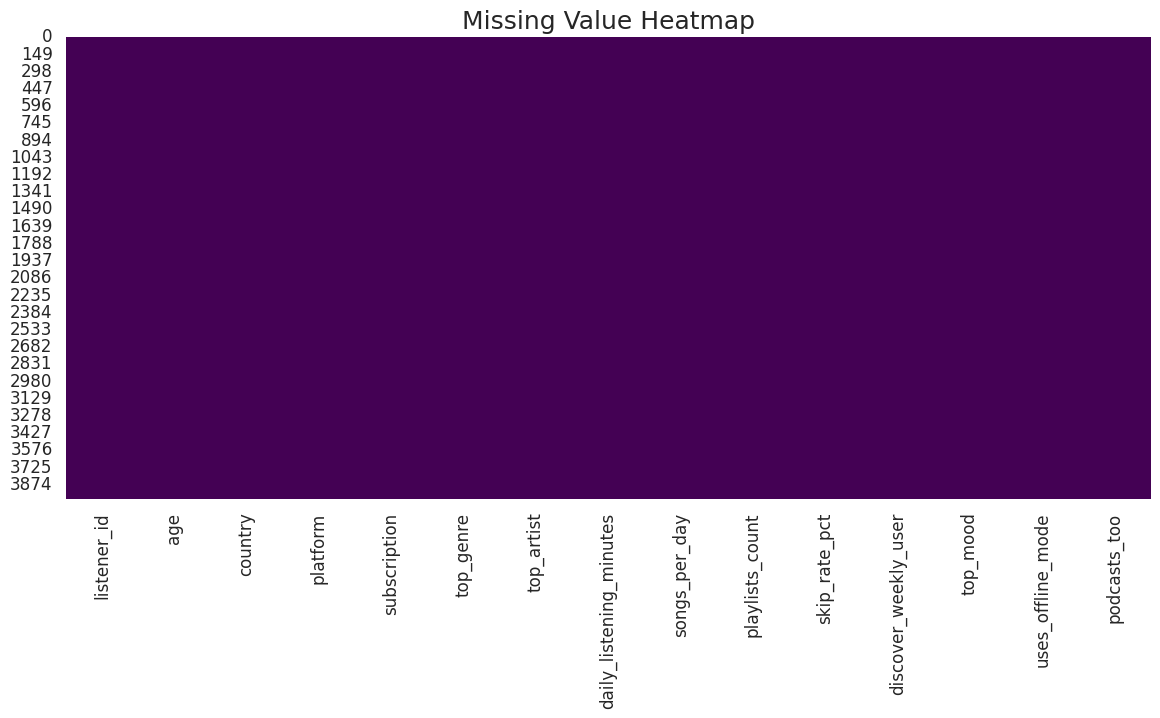


Numerical Columns
Index(['listener_id', 'age', 'daily_listening_minutes', 'songs_per_day',
       'playlists_count', 'skip_rate_pct'],
      dtype='object')

Categorical Columns
Index(['country', 'platform', 'subscription', 'top_genre', 'top_artist',
       'top_mood'],
      dtype='object')


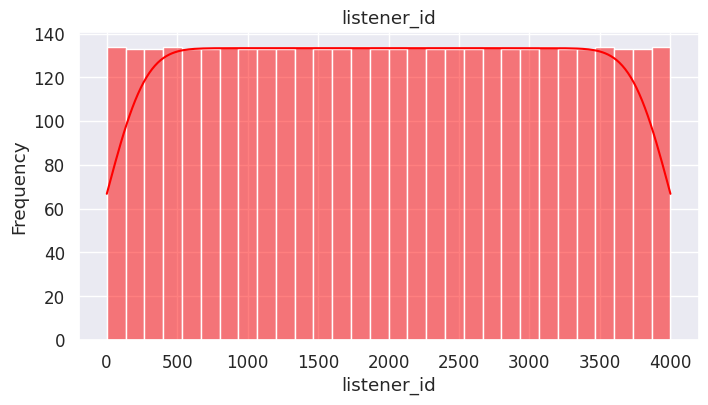

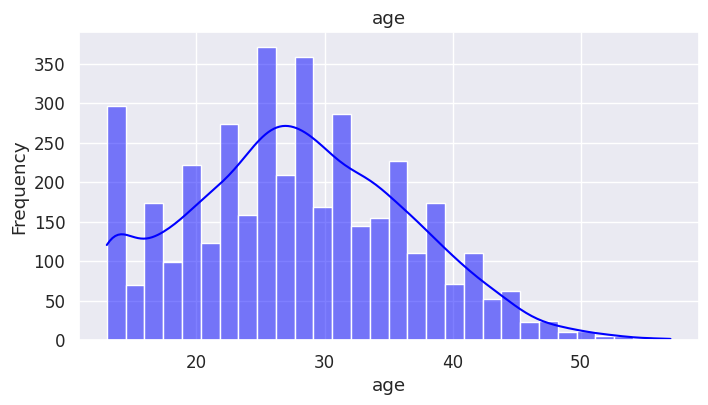

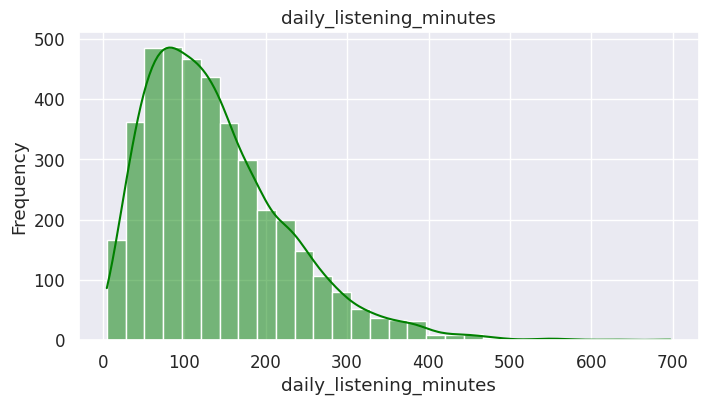

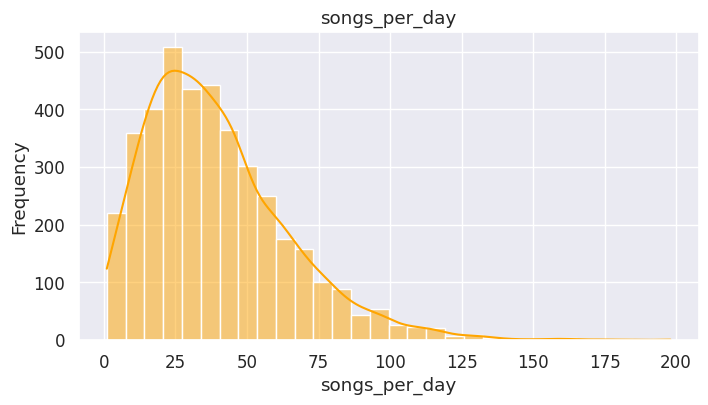

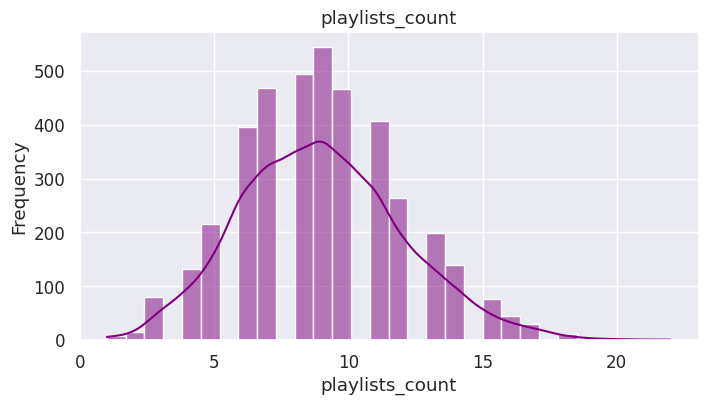

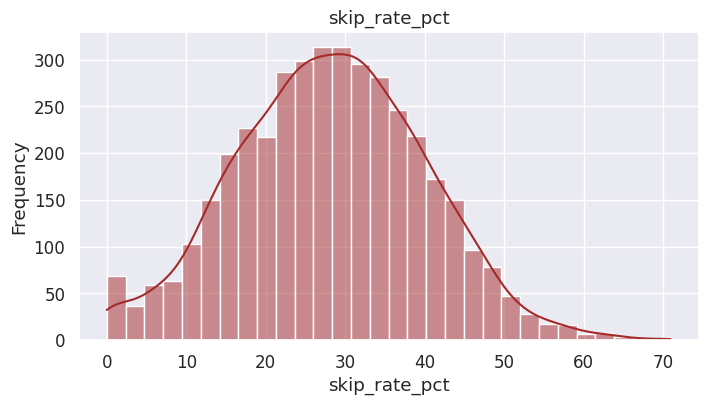

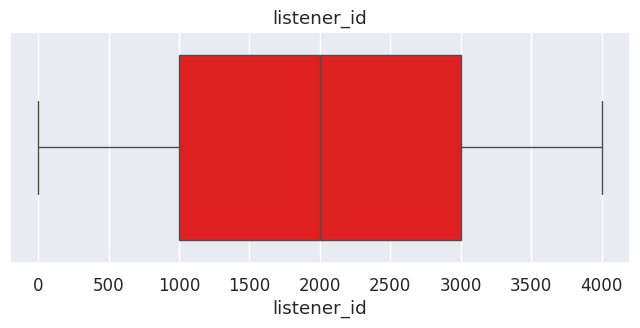

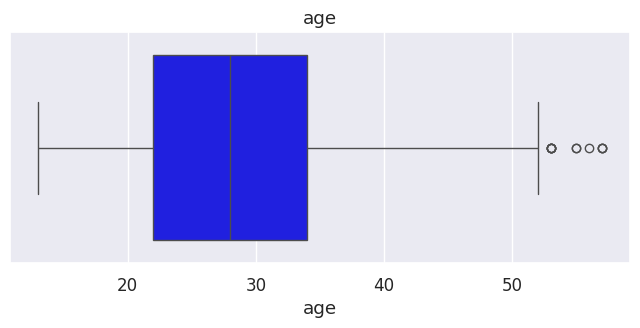

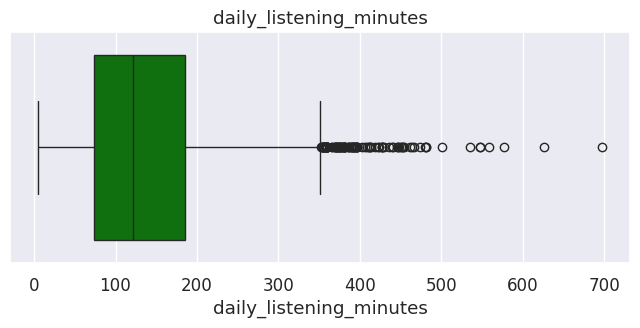

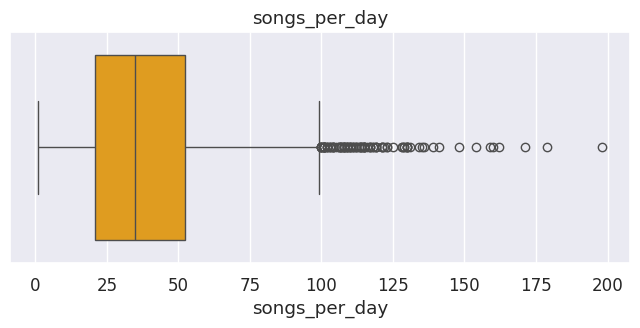

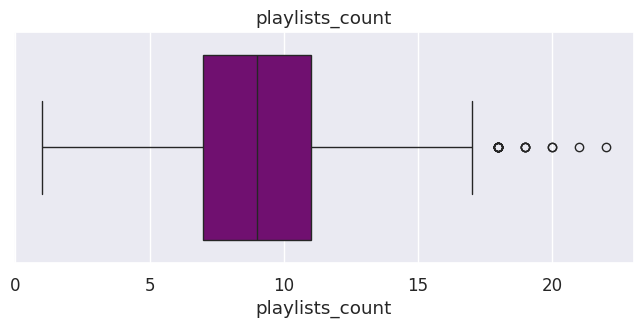

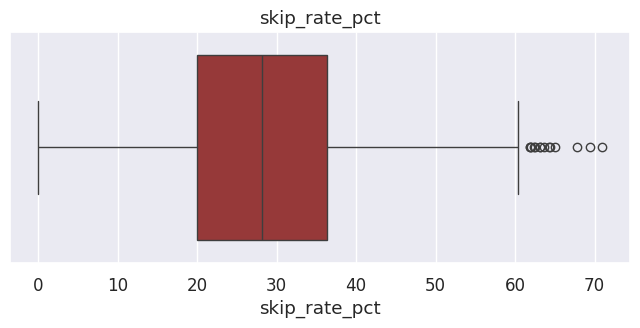

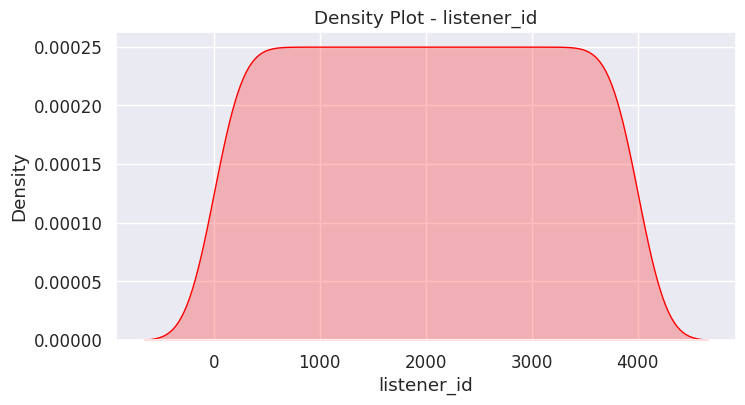

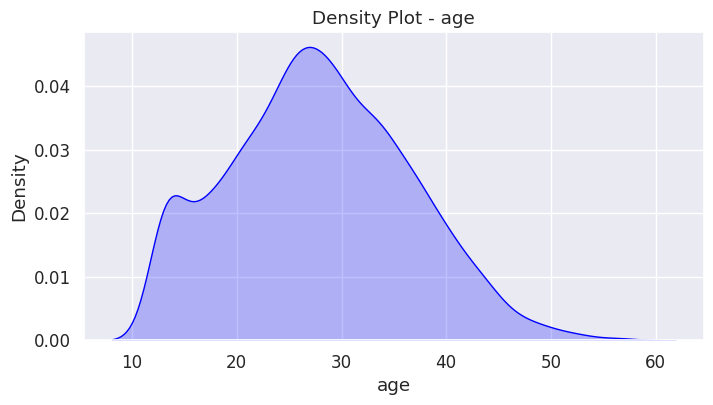

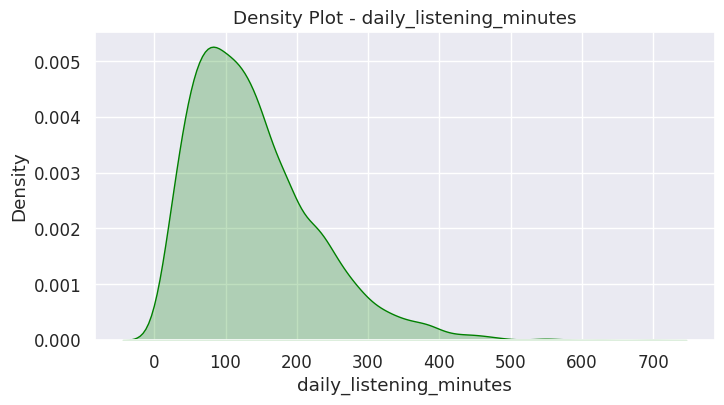

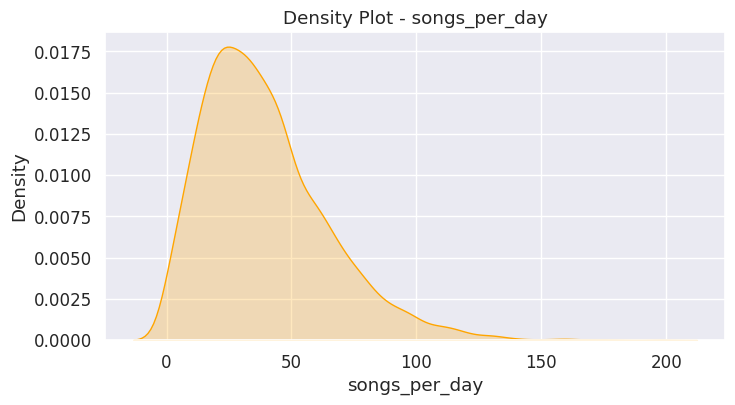

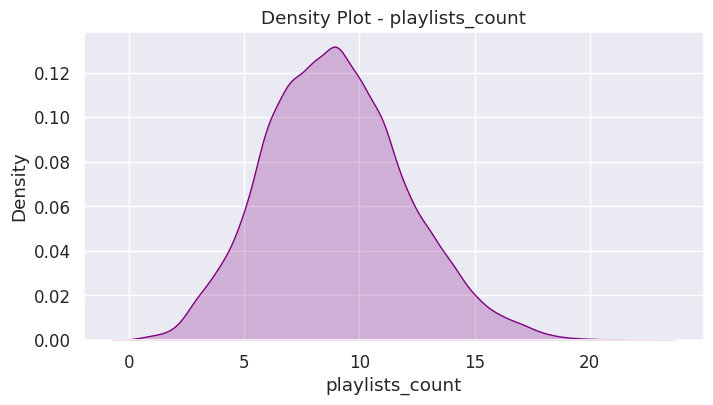

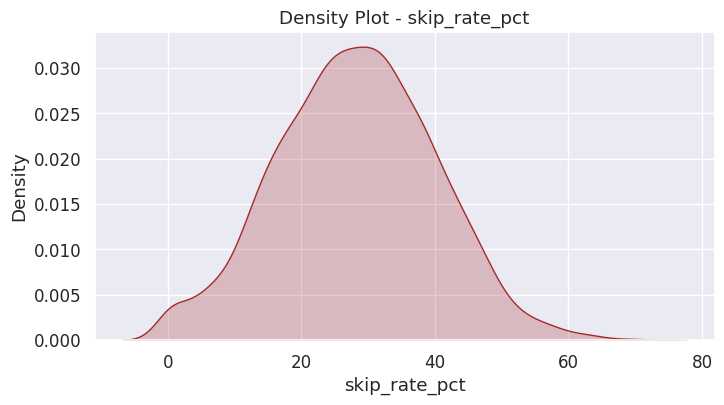

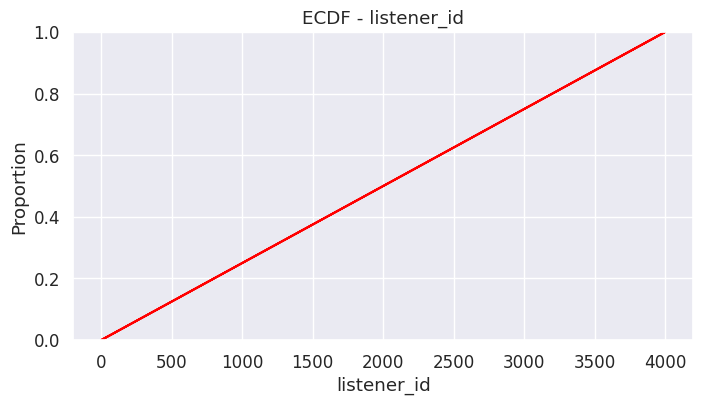

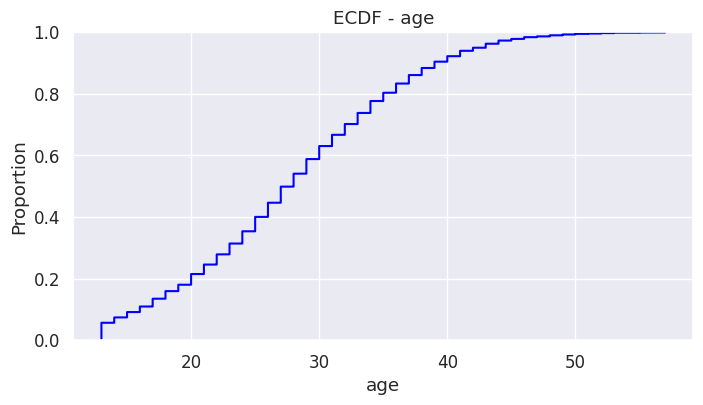

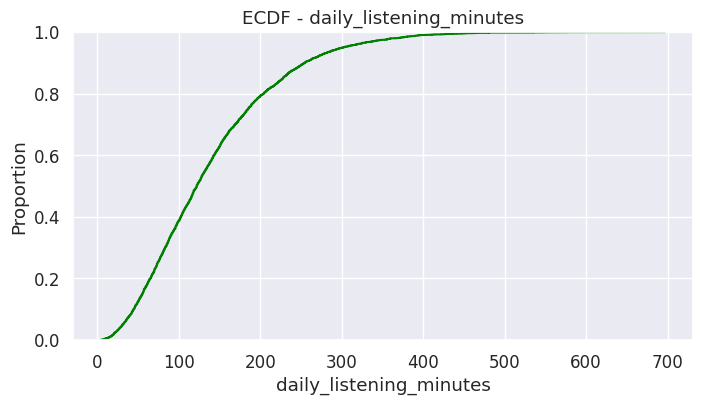

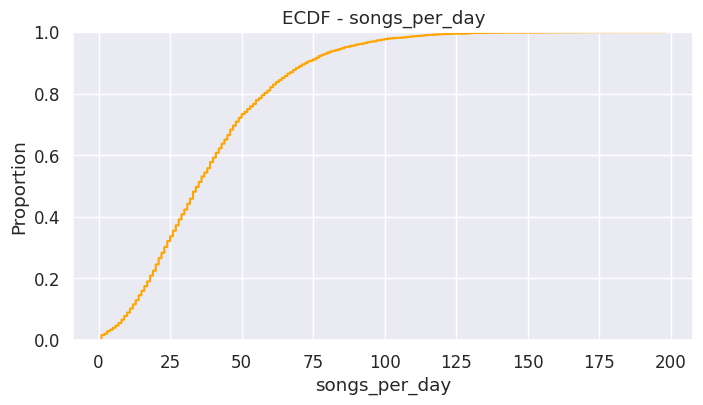

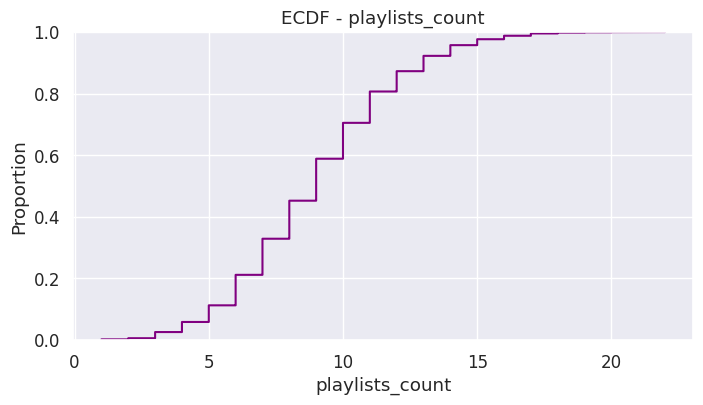

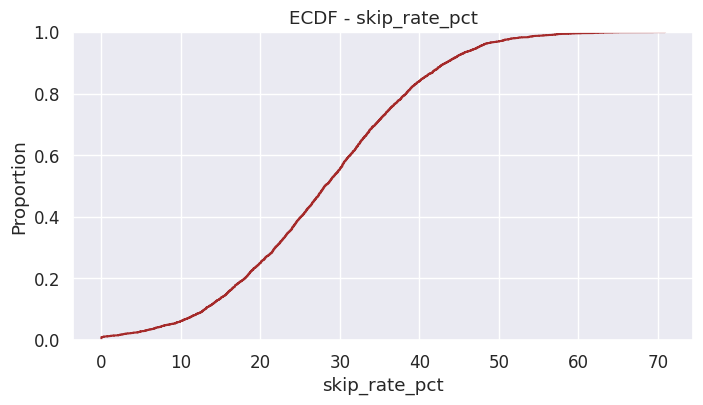

PART 1 COMPLETED


In [12]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.1)

data = df.copy()

# ==========================================================
# DATASET OVERVIEW
# ==========================================================

print("="*70)
print("DATASET SHAPE")
print(data.shape)

print("="*70)
print("FIRST 5 ROWS")
print(data.head())

print("="*70)
print("DATA INFO")
print(data.info())

print("="*70)
print("MISSING VALUES")
print(data.isnull().sum())

print("="*70)
print("STATISTICAL SUMMARY")
print(data.describe(include="all"))

# ==========================================================
# MISSING VALUE HEATMAP
# ==========================================================

plt.figure(figsize=(14,6))

sns.heatmap(
    data.isnull(),
    cmap="viridis",
    cbar=False
)

plt.title("Missing Value Heatmap",fontsize=18)

plt.show()

# ==========================================================
# NUMERICAL & CATEGORICAL COLUMNS
# ==========================================================

num_cols = data.select_dtypes(include=np.number).columns

cat_cols = data.select_dtypes(include="object").columns

print("\nNumerical Columns")
print(num_cols)

print("\nCategorical Columns")
print(cat_cols)

# ==========================================================
# HISTOGRAMS
# ==========================================================

colors = [
"red","blue","green","orange",
"purple","brown","cyan","magenta",
"gold","pink","olive","teal"
]

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.histplot(
        data[col],
        bins=30,
        kde=True,
        color=colors[i%len(colors)]
    )

    plt.title(col)

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

# ==========================================================
# BOXPLOTS
# ==========================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=data[col],
        color=colors[i%len(colors)]
    )

    plt.title(col)

    plt.show()

# ==========================================================
# KDE PLOTS
# ==========================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        data[col],
        fill=True,
        color=colors[i%len(colors)]
    )

    plt.title("Density Plot - "+col)

    plt.show()

# ==========================================================
# ECDF PLOTS
# ==========================================================

for i,col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.ecdfplot(
        data[col],
        color=colors[i%len(colors)]
    )

    plt.title("ECDF - "+col)

    plt.show()

print("="*70)
print("PART 1 COMPLETED")
print("="*70)

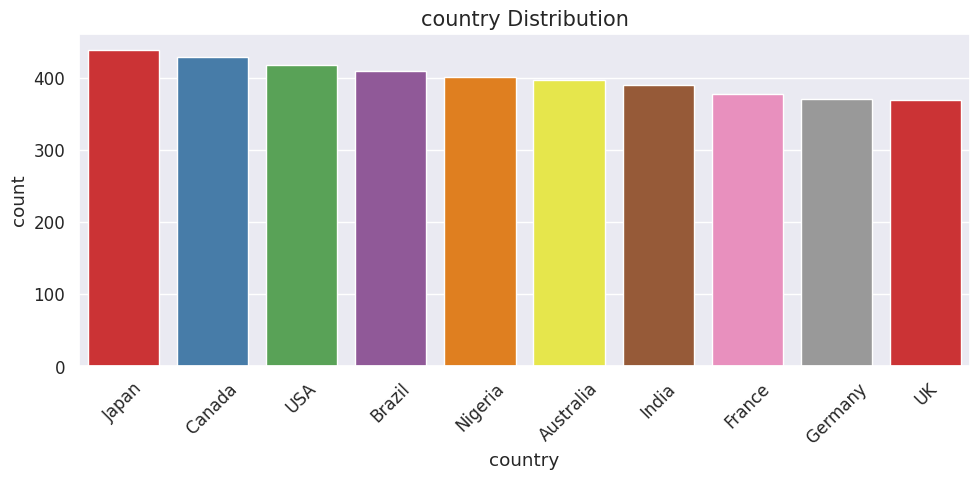

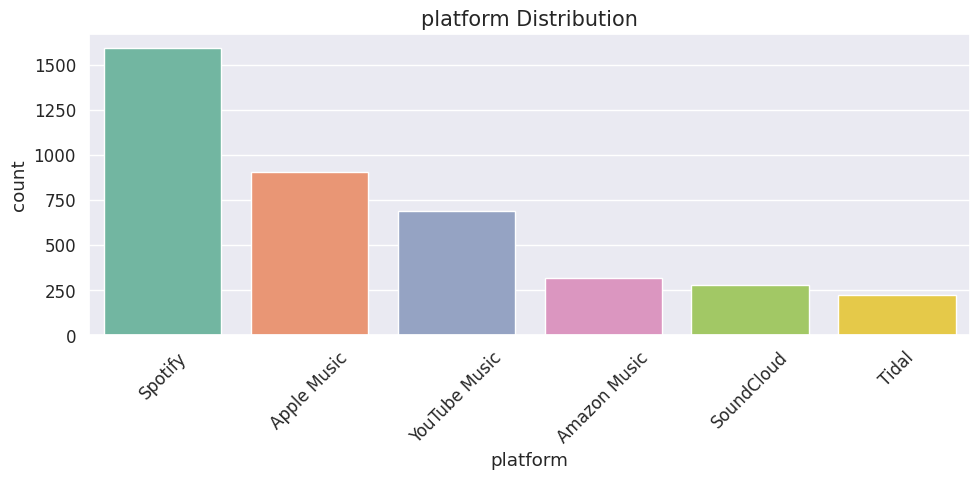

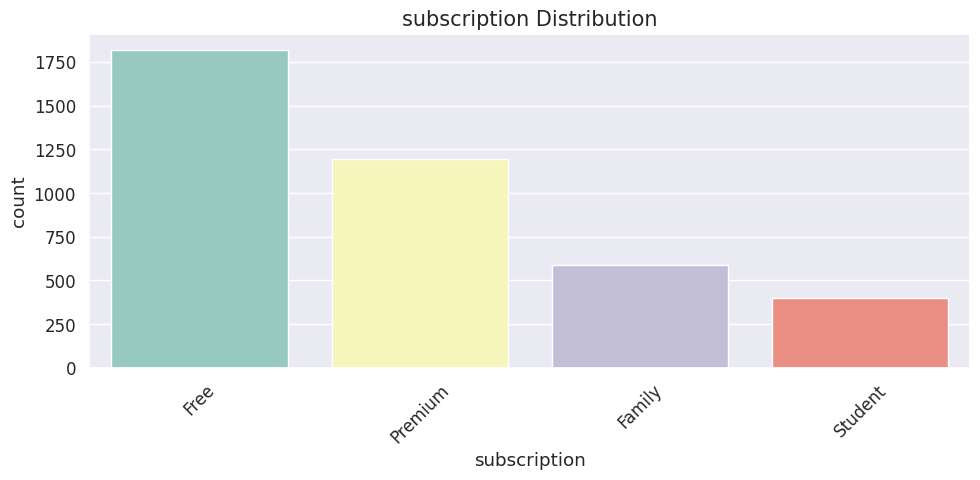

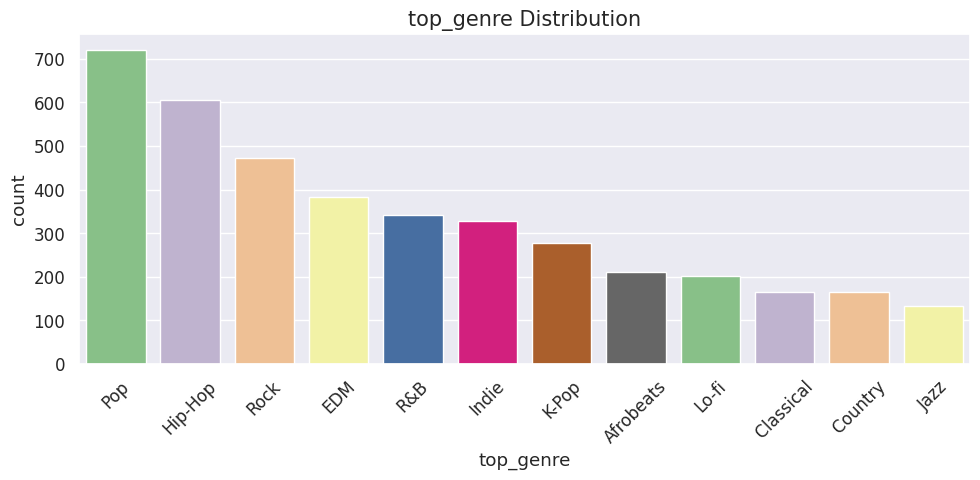

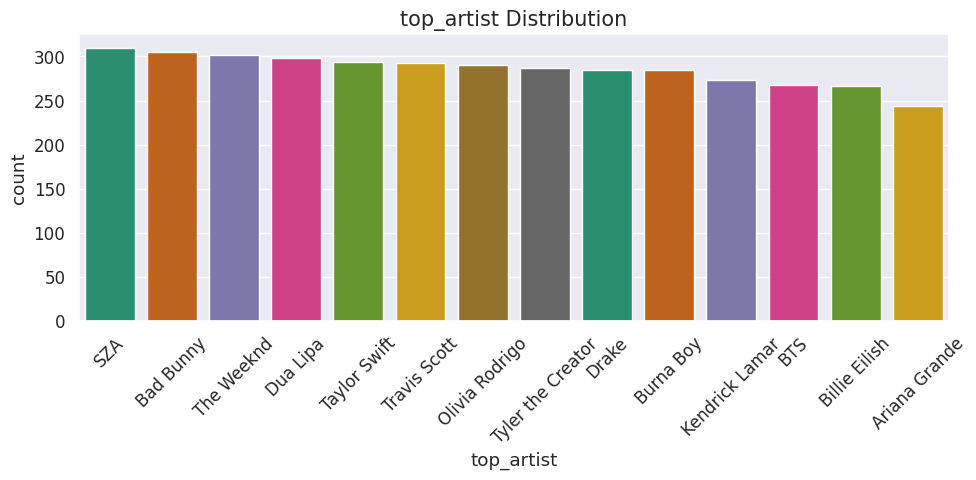

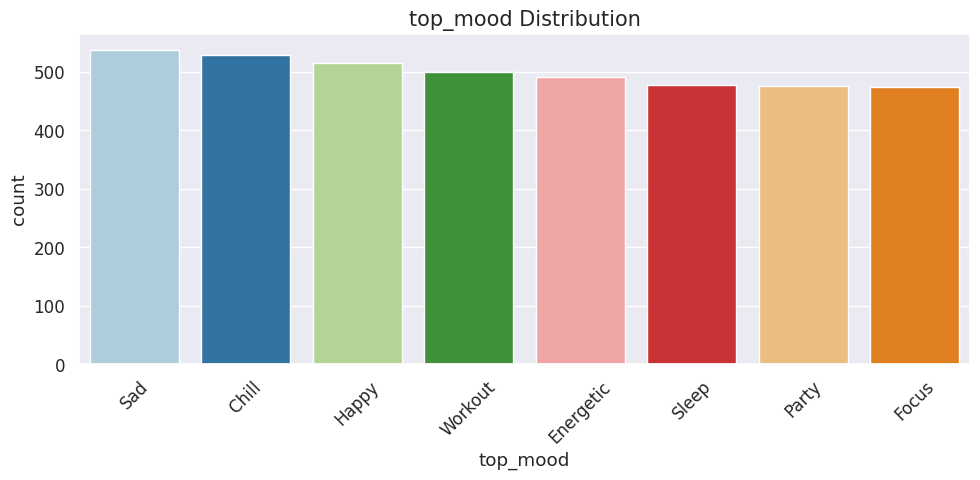

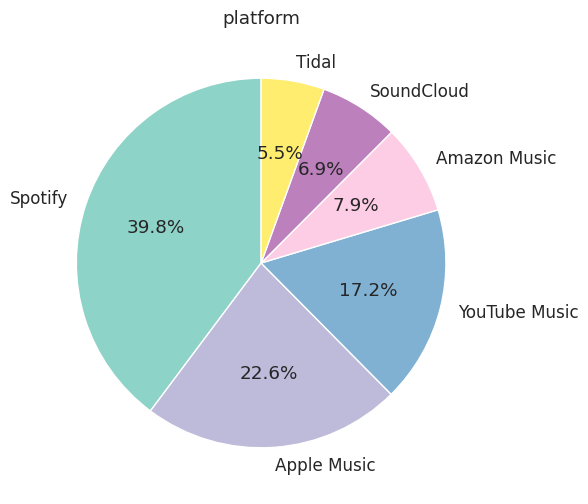

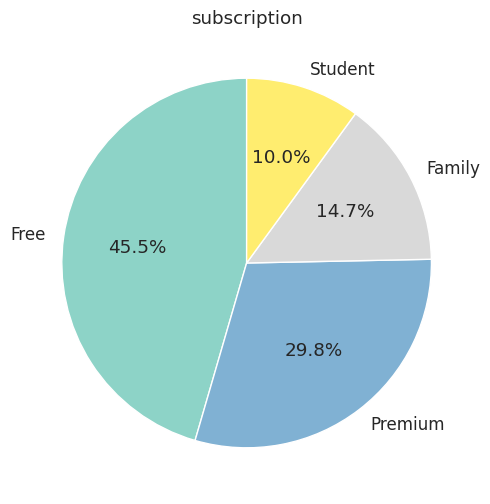

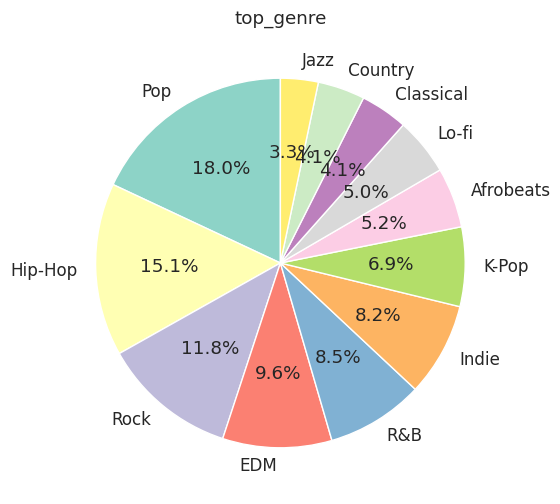

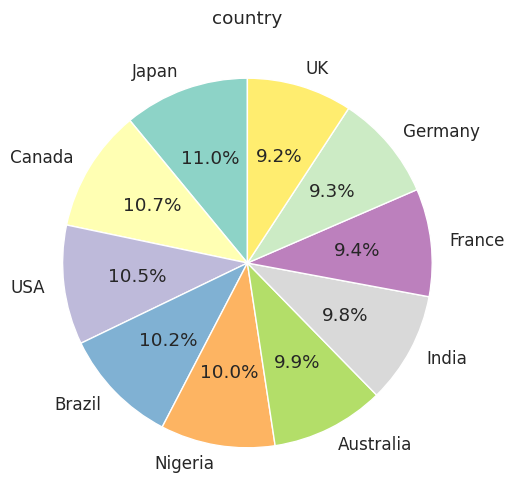

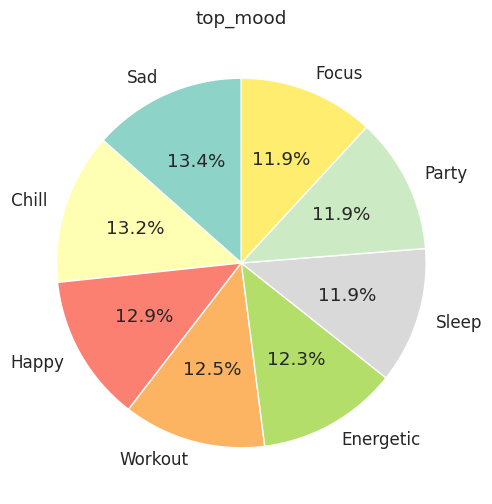

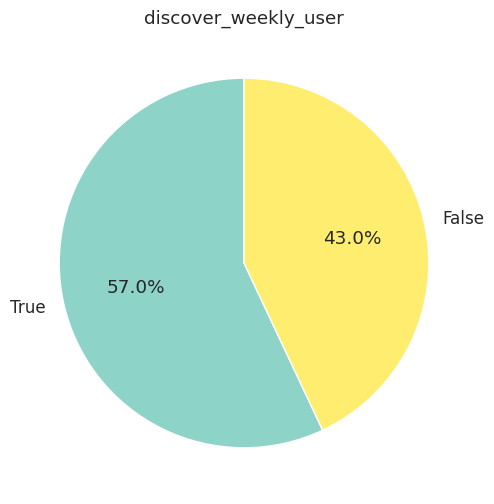

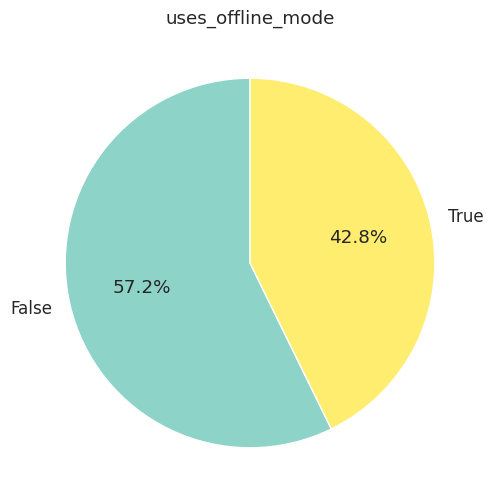

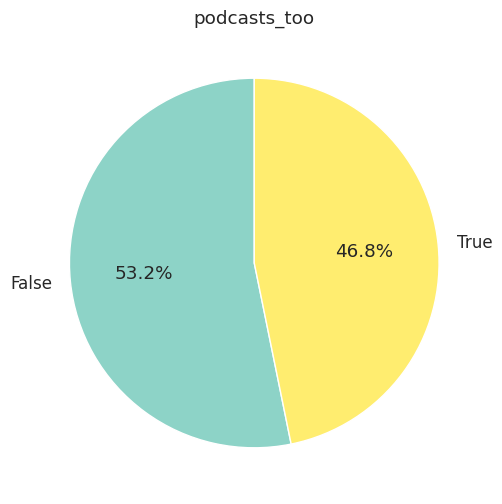

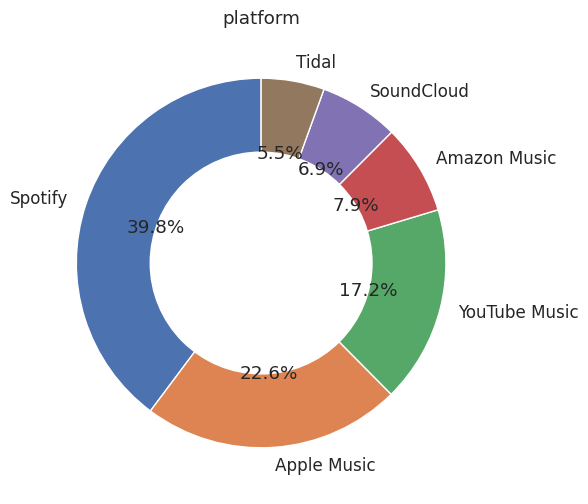

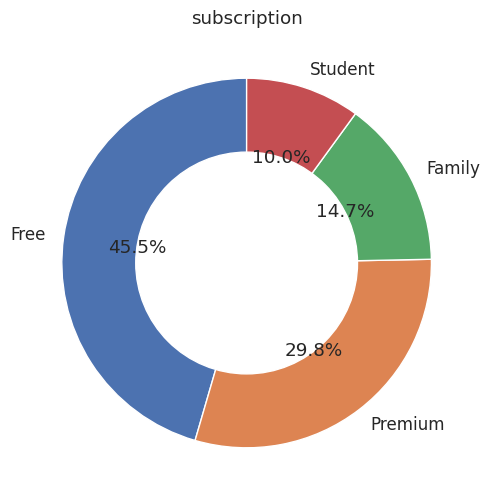

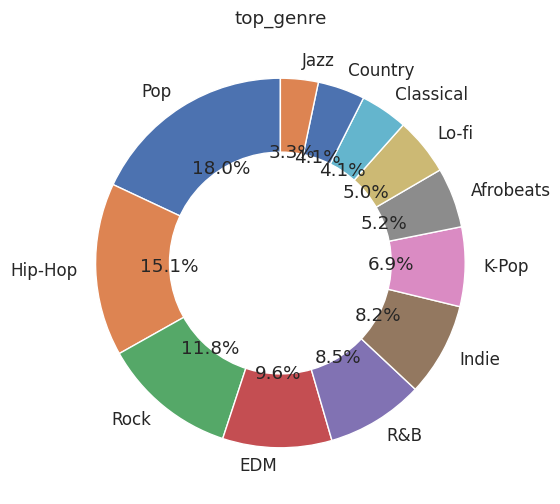

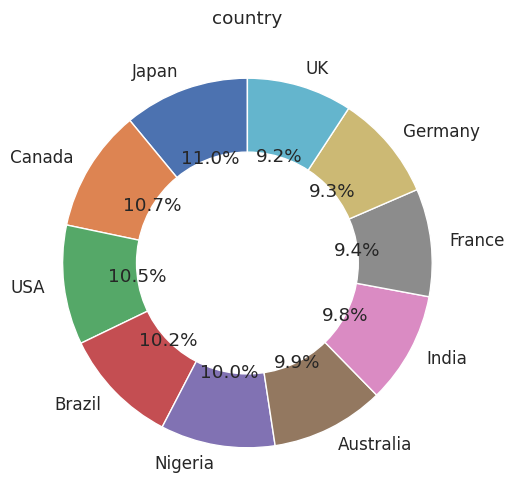

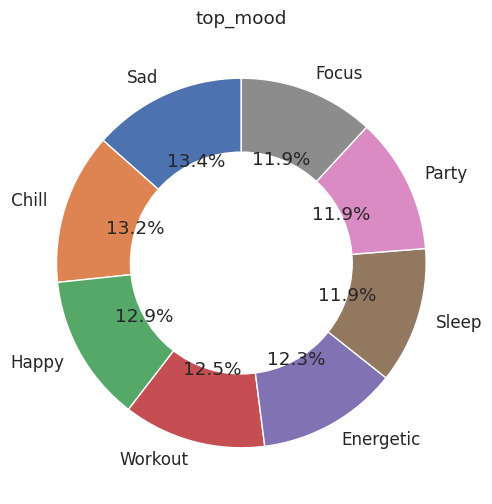

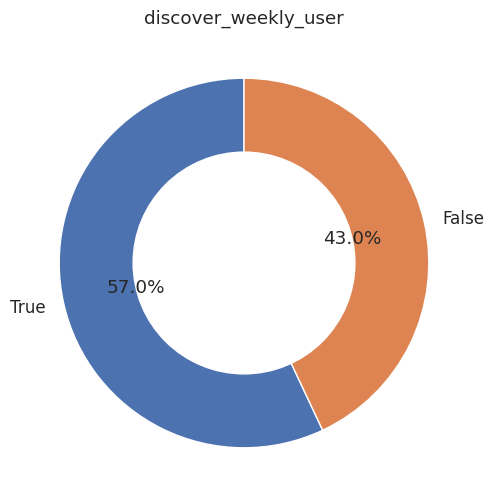

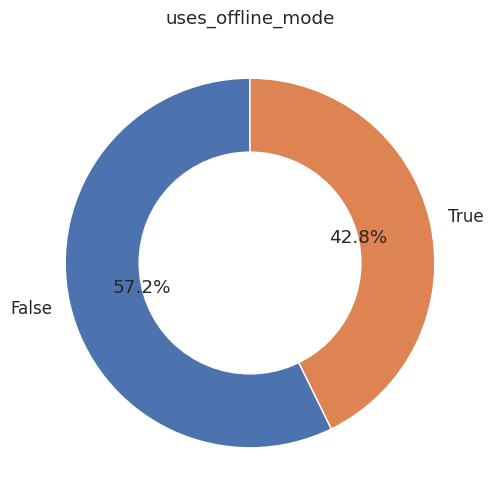

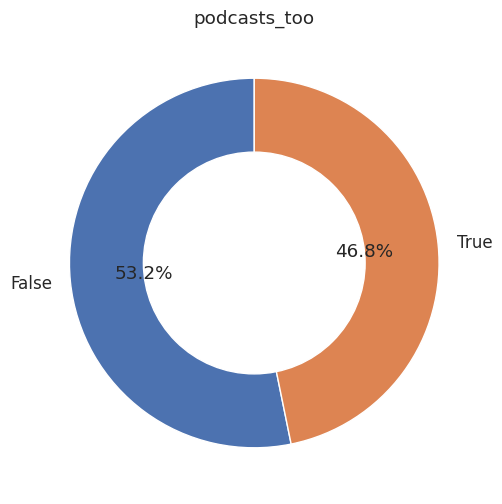

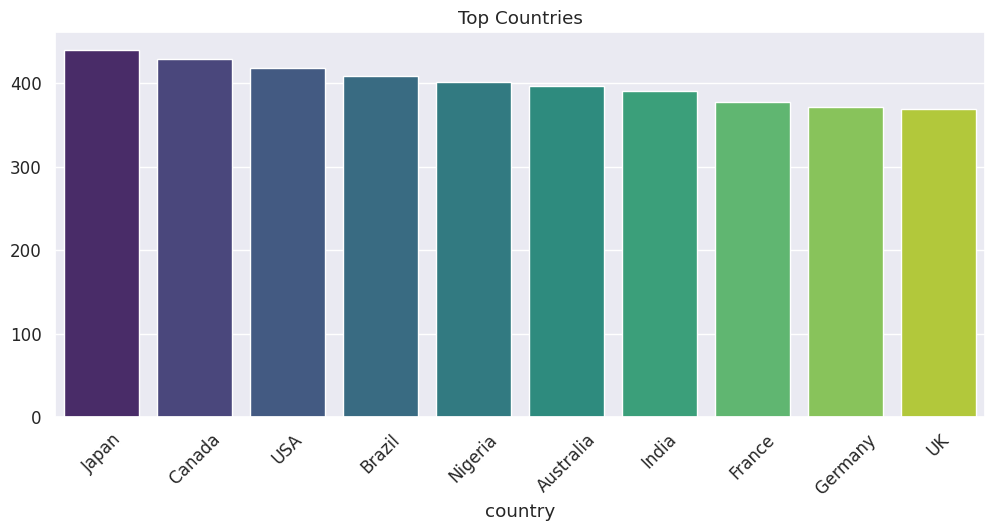

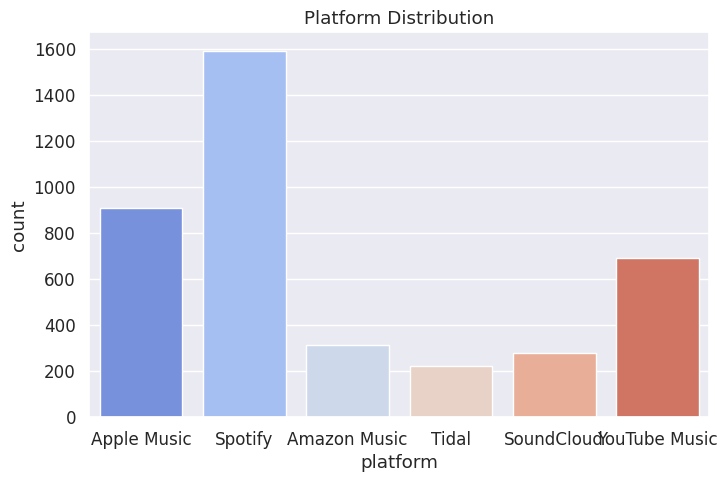

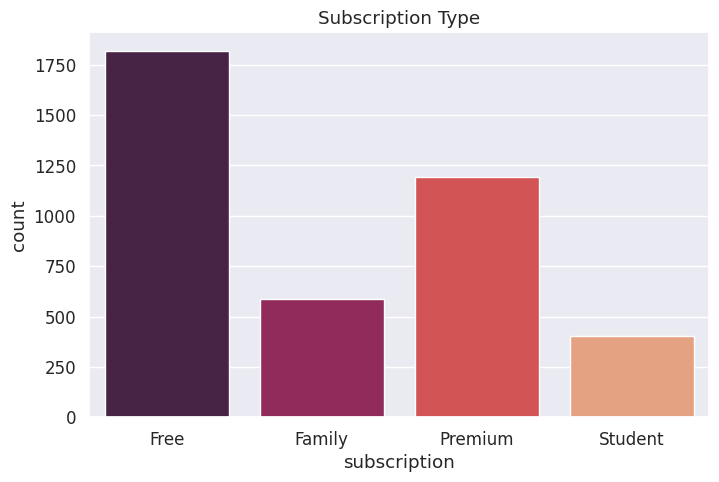

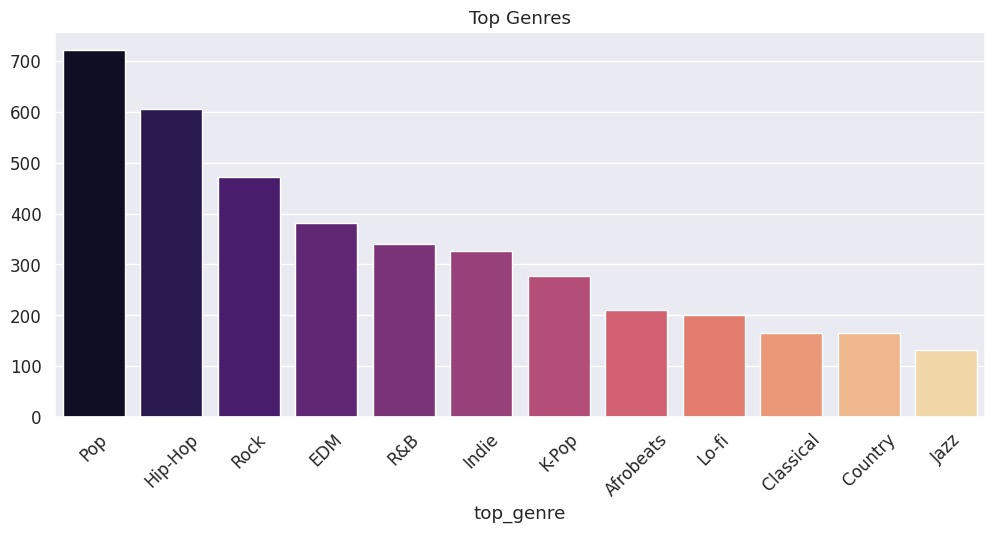

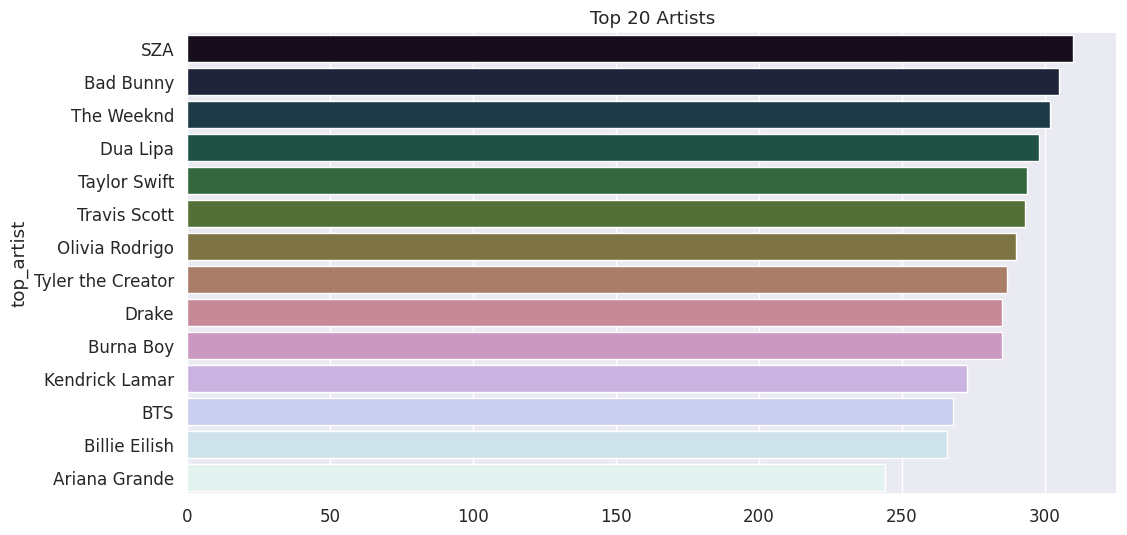

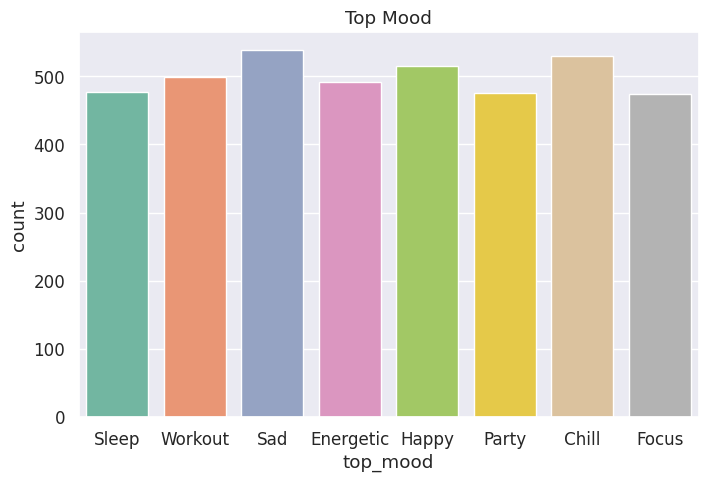

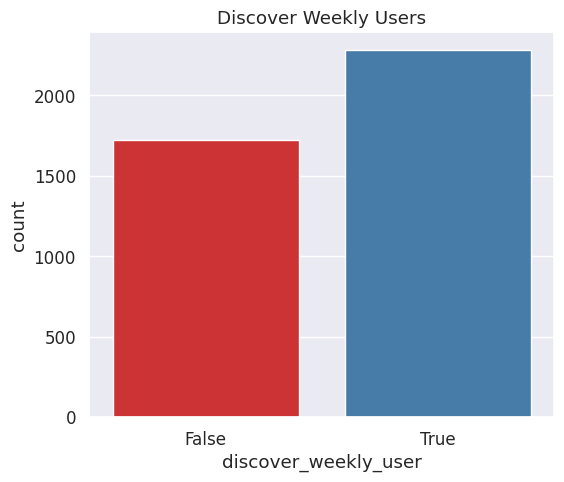

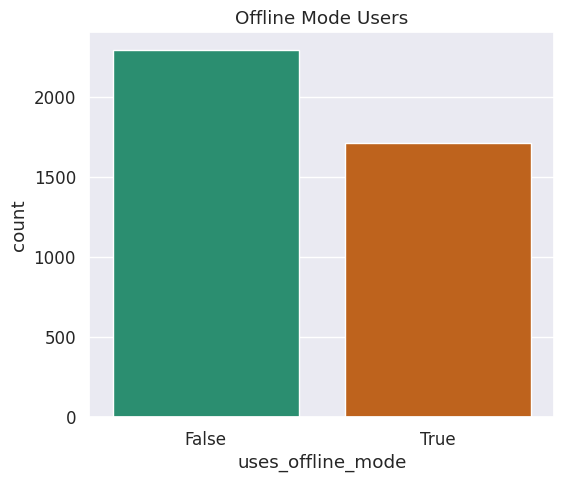

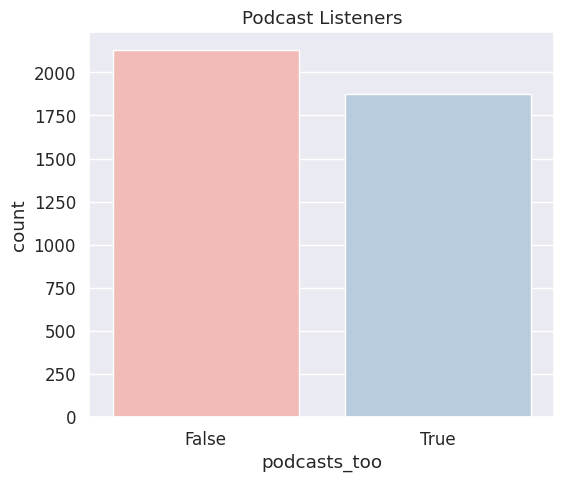

PART 2 COMPLETED


In [13]:
# ==========================================================
# PART 2 : CATEGORICAL VISUALIZATION
# ==========================================================

palettes = [
    "Set1",
    "Set2",
    "Set3",
    "Accent",
    "Dark2",
    "Paired",
    "Pastel1",
    "Pastel2",
    "rocket",
    "mako",
    "crest",
    "flare",
    "viridis",
    "Spectral",
    "coolwarm"
]

# ==========================================================
# COUNTPLOTS FOR EVERY CATEGORICAL COLUMN
# ==========================================================

for i, col in enumerate(cat_cols):

    plt.figure(figsize=(10,5))

    order = data[col].value_counts().index

    sns.countplot(
        data=data,
        x=col,
        order=order,
        palette=palettes[i % len(palettes)]
    )

    plt.title(f"{col} Distribution", fontsize=15)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

# ==========================================================
# PIE CHARTS
# ==========================================================

important_cols = [
    "platform",
    "subscription",
    "top_genre",
    "country",
    "top_mood",
    "discover_weekly_user",
    "uses_offline_mode",
    "podcasts_too"
]

for col in important_cols:

    if col in data.columns:

        plt.figure(figsize=(6,6))

        data[col].value_counts().plot(
            kind="pie",
            autopct="%1.1f%%",
            startangle=90,
            cmap="Set3"
        )

        plt.ylabel("")

        plt.title(col)

        plt.show()

# ==========================================================
# DONUT CHARTS
# ==========================================================

for col in important_cols:

    if col in data.columns:

        counts = data[col].value_counts()

        fig, ax = plt.subplots(figsize=(6,6))

        ax.pie(
            counts,
            labels=counts.index,
            autopct="%1.1f%%",
            startangle=90
        )

        centre = plt.Circle((0,0),0.60,fc="white")

        fig.gca().add_artist(centre)

        plt.title(col)

        plt.show()

# ==========================================================
# TOP COUNTRIES
# ==========================================================

plt.figure(figsize=(12,5))

country = data["country"].value_counts().head(15)

sns.barplot(
    x=country.index,
    y=country.values,
    palette="viridis"
)

plt.title("Top Countries")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# PLATFORM DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="platform",
    palette="coolwarm"
)

plt.title("Platform Distribution")

plt.show()

# ==========================================================
# SUBSCRIPTION TYPE
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="subscription",
    palette="rocket"
)

plt.title("Subscription Type")

plt.show()

# ==========================================================
# TOP GENRE
# ==========================================================

plt.figure(figsize=(12,5))

genre = data["top_genre"].value_counts().head(15)

sns.barplot(
    x=genre.index,
    y=genre.values,
    palette="magma"
)

plt.title("Top Genres")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# TOP ARTISTS
# ==========================================================

plt.figure(figsize=(12,6))

artist = data["top_artist"].value_counts().head(20)

sns.barplot(
    x=artist.values,
    y=artist.index,
    palette="cubehelix"
)

plt.title("Top 20 Artists")

plt.show()

# ==========================================================
# MOOD ANALYSIS
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="top_mood",
    palette="Set2"
)

plt.title("Top Mood")

plt.show()

# ==========================================================
# DISCOVER WEEKLY USERS
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=data,
    x="discover_weekly_user",
    palette="Set1"
)

plt.title("Discover Weekly Users")

plt.show()

# ==========================================================
# OFFLINE MODE
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=data,
    x="uses_offline_mode",
    palette="Dark2"
)

plt.title("Offline Mode Users")

plt.show()

# ==========================================================
# PODCAST USERS
# ==========================================================

plt.figure(figsize=(6,5))

sns.countplot(
    data=data,
    x="podcasts_too",
    palette="Pastel1"
)

plt.title("Podcast Listeners")

plt.show()

print("="*70)
print("PART 2 COMPLETED")
print("="*70)

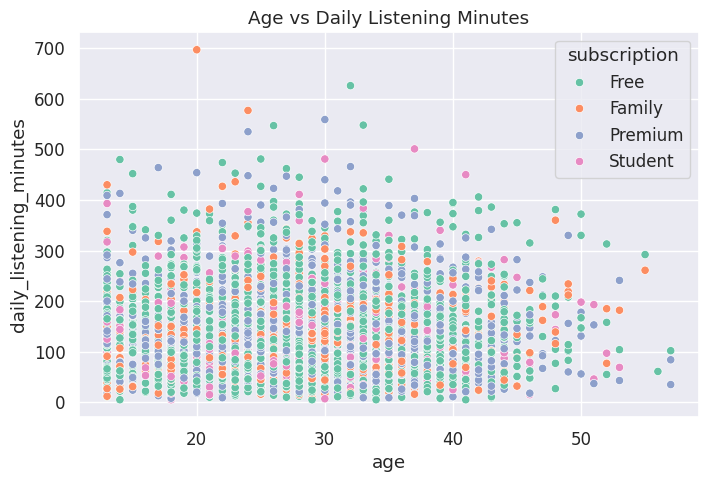

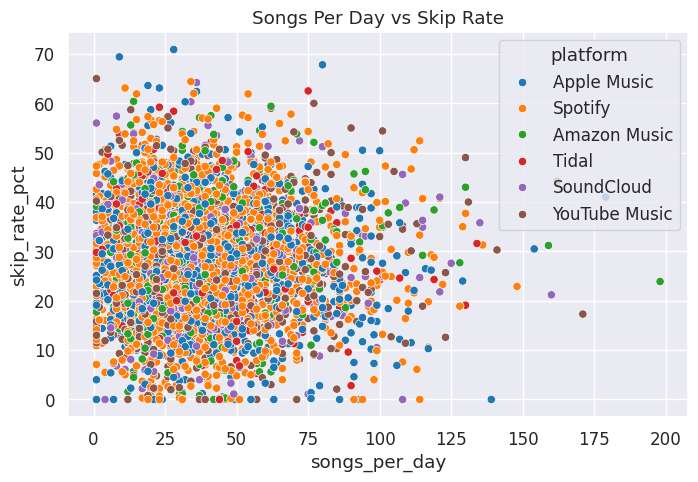

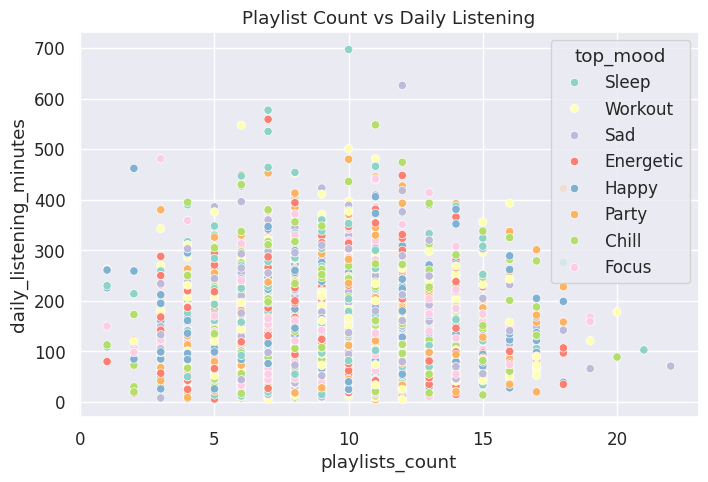

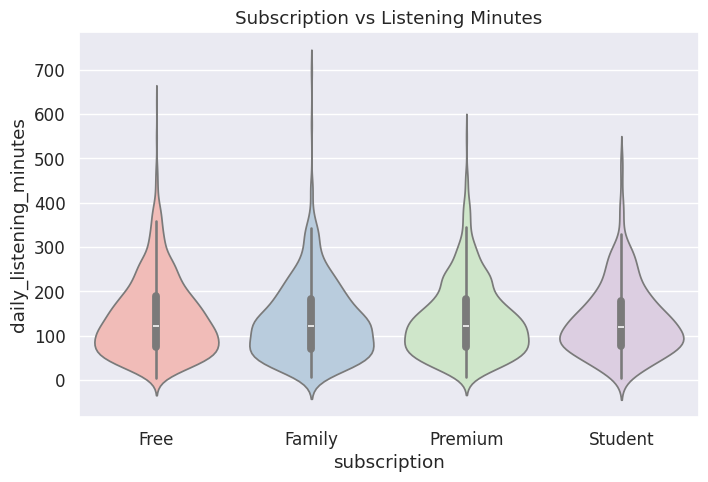

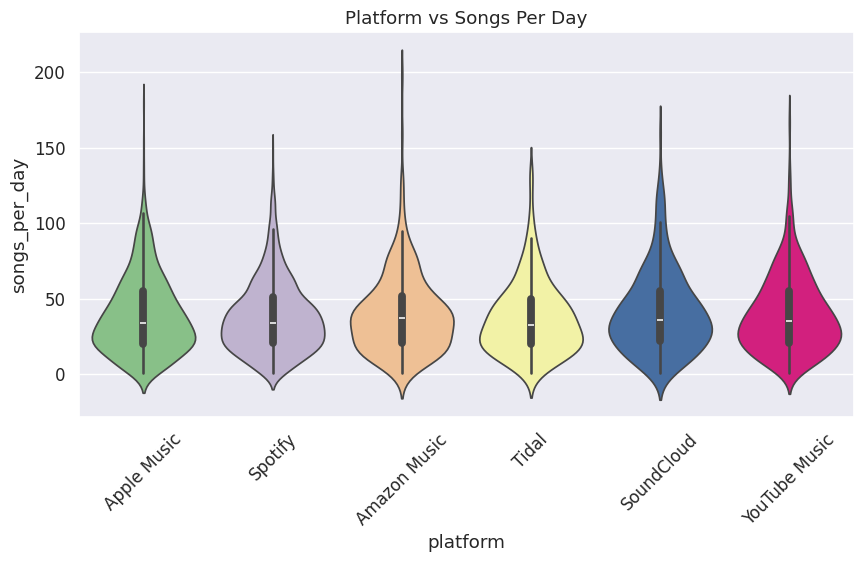

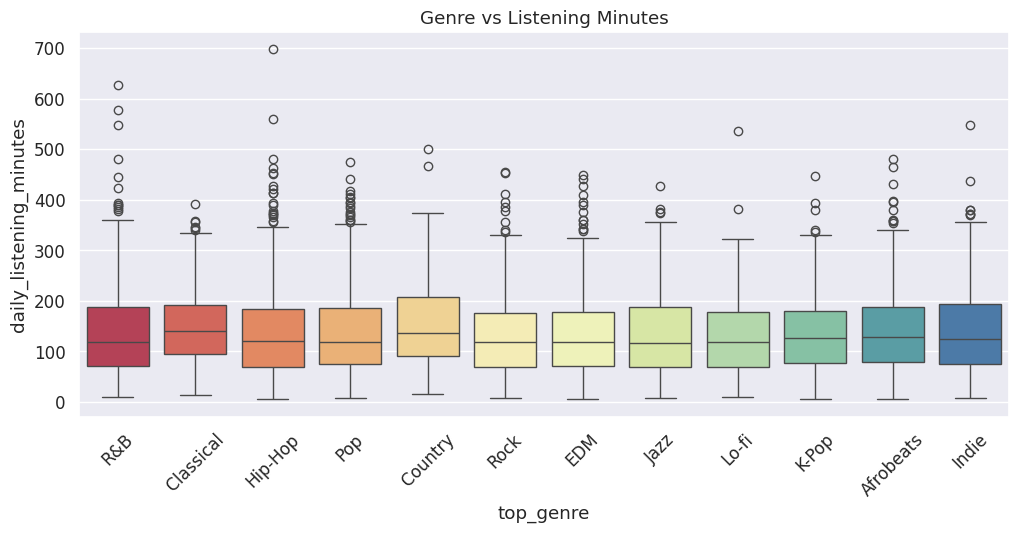

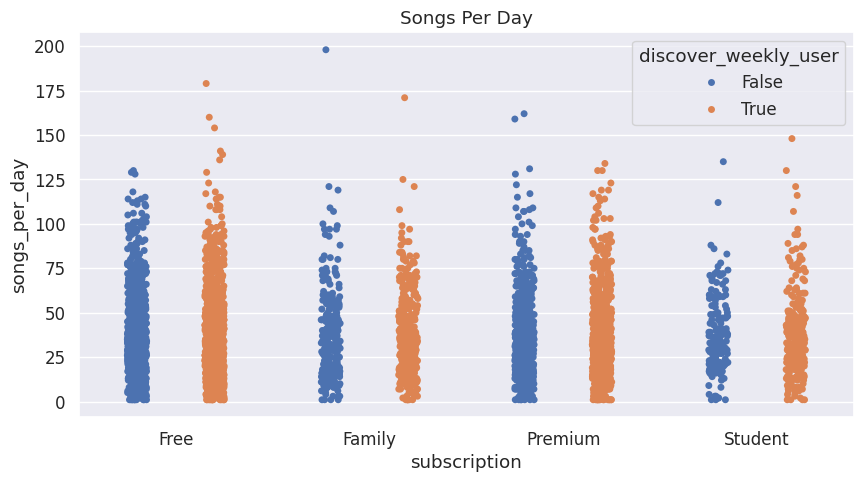

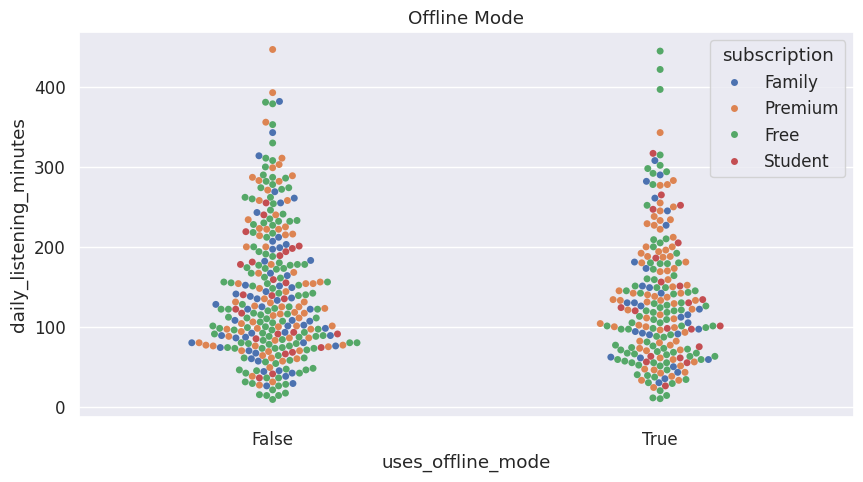

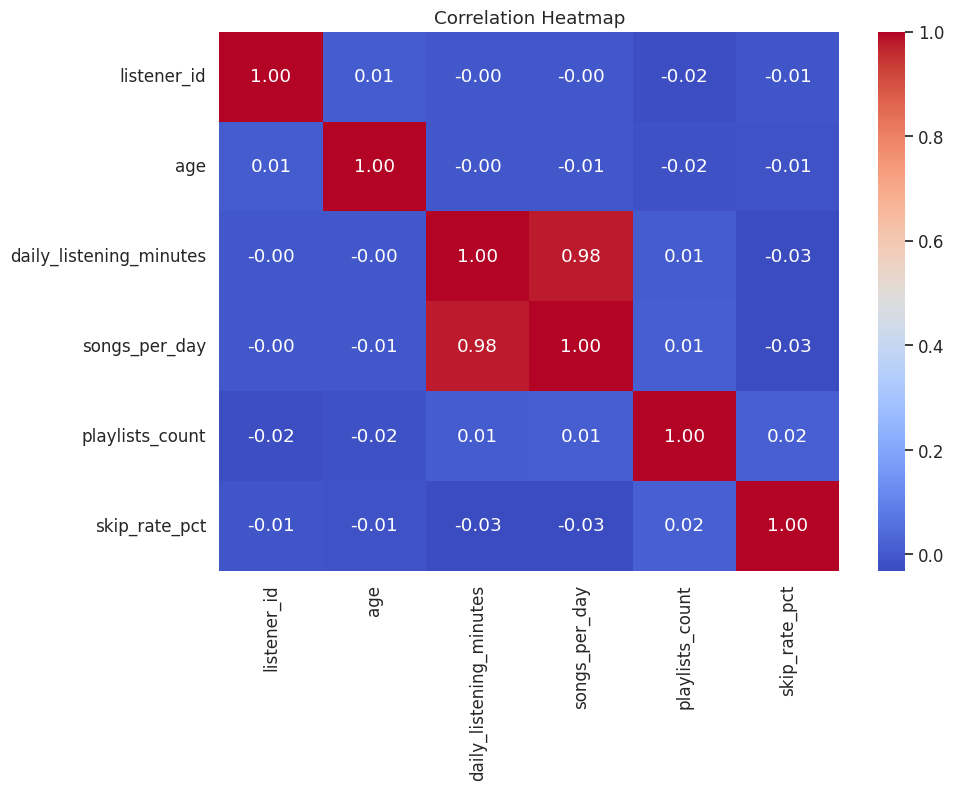

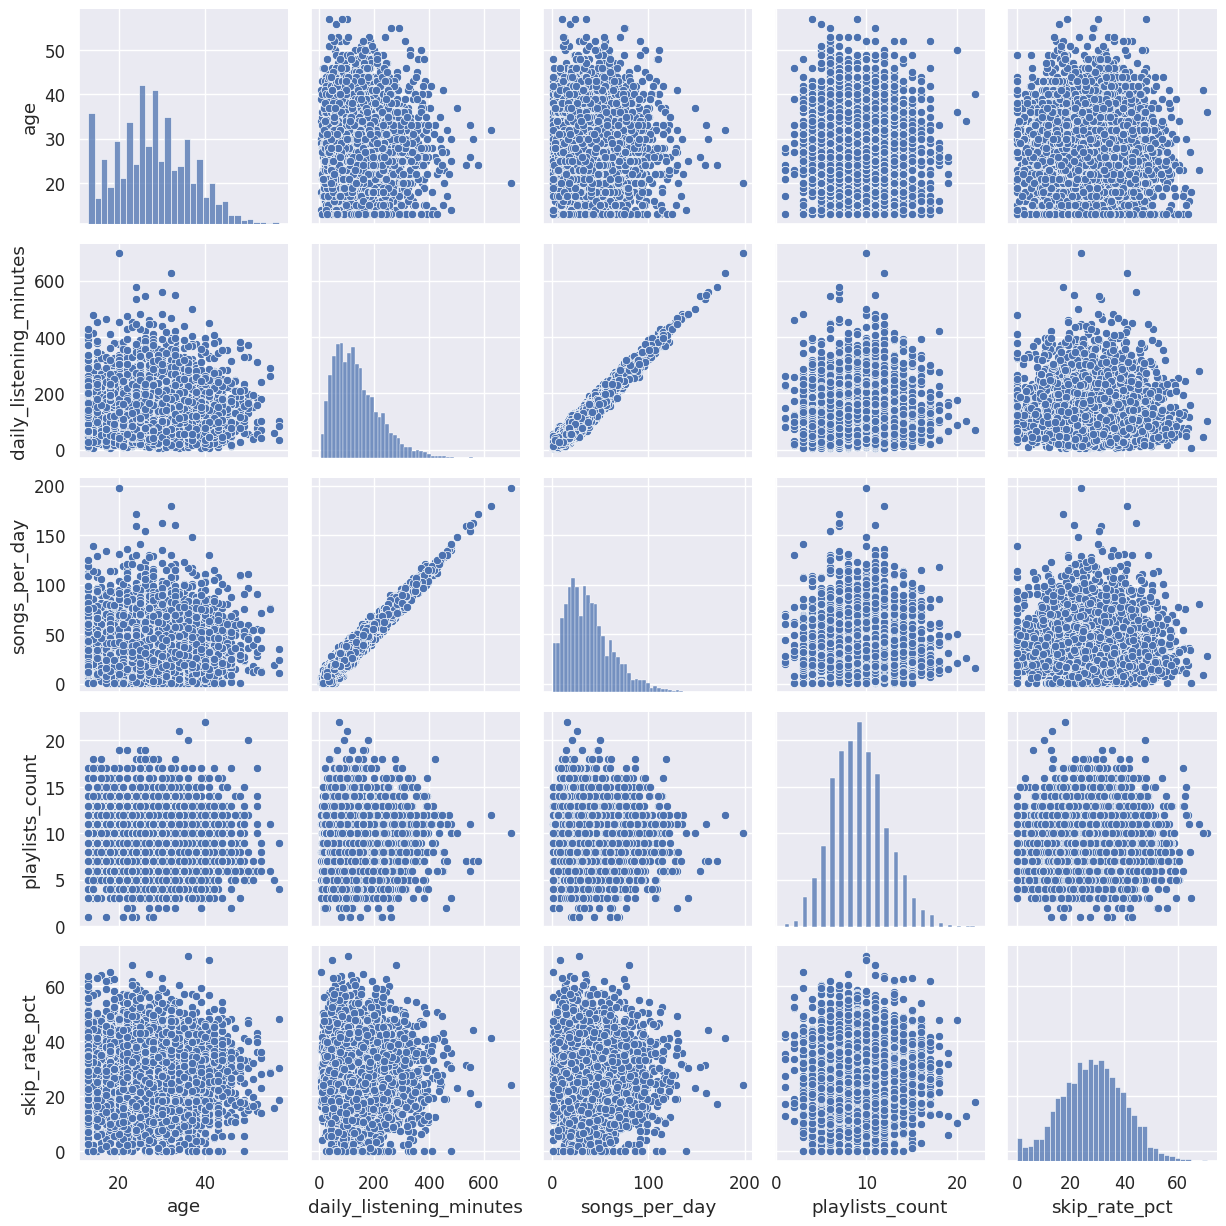

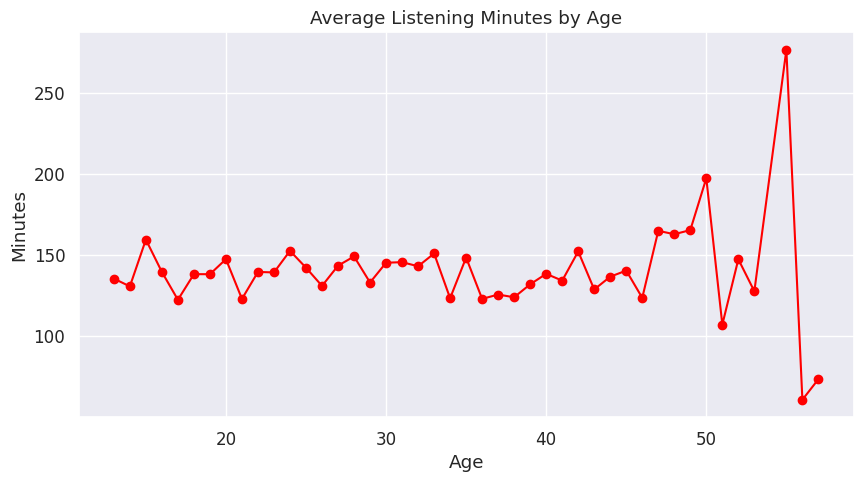

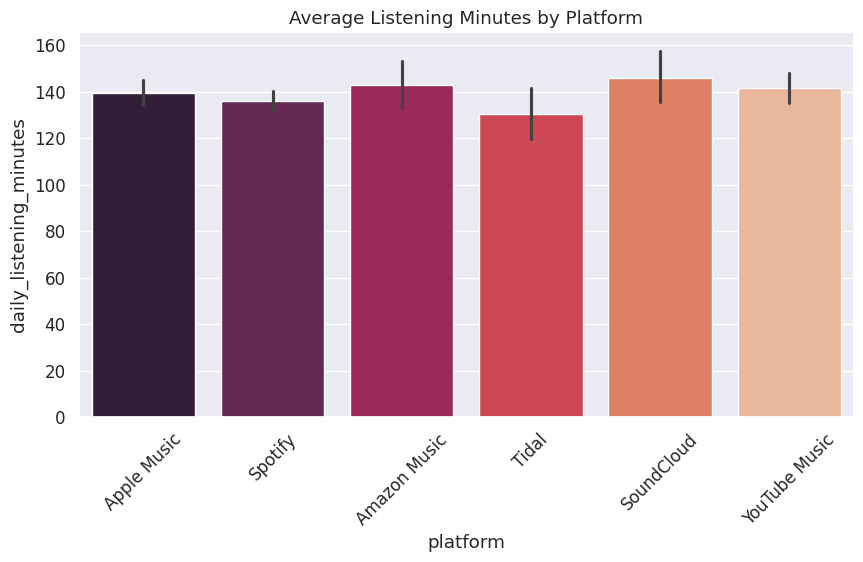

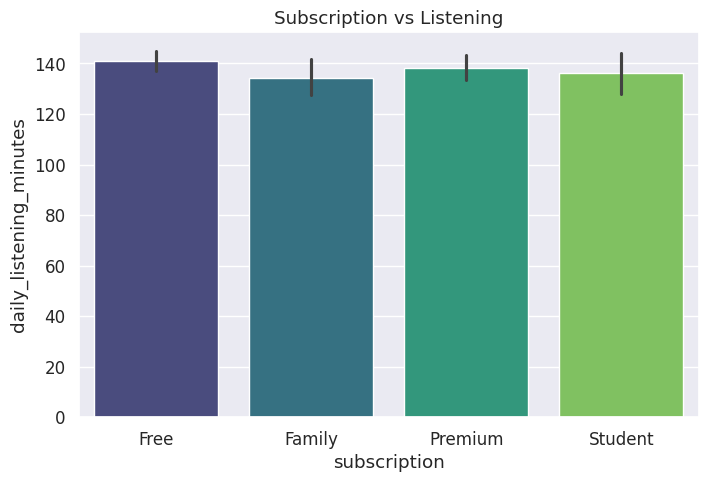

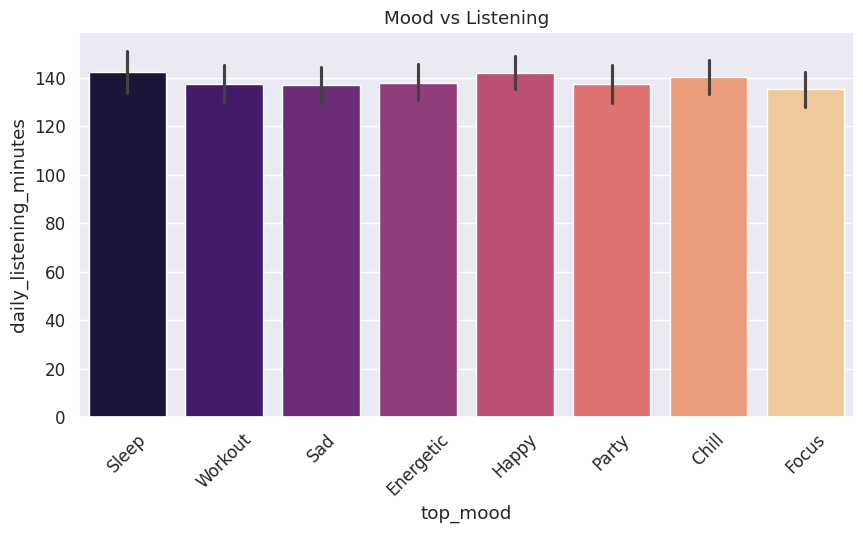

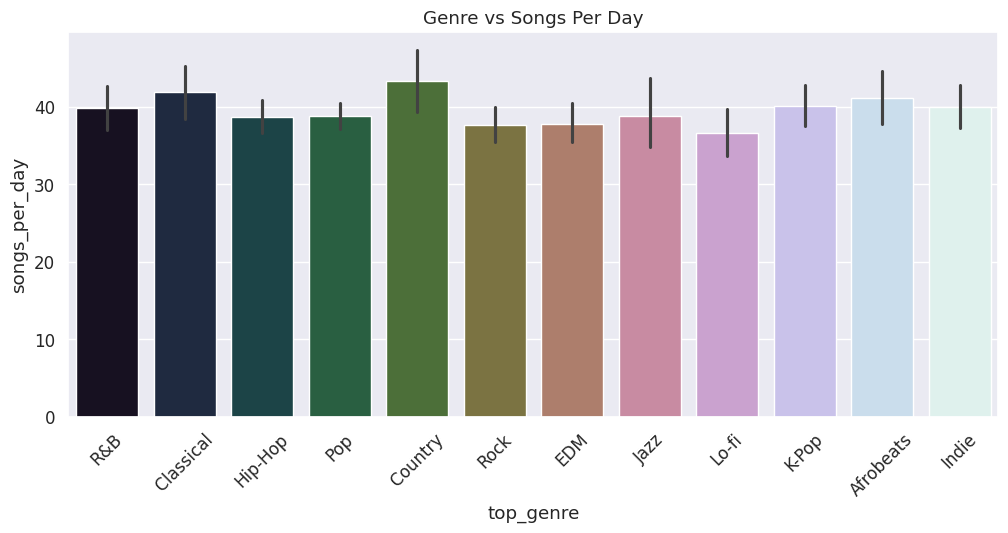

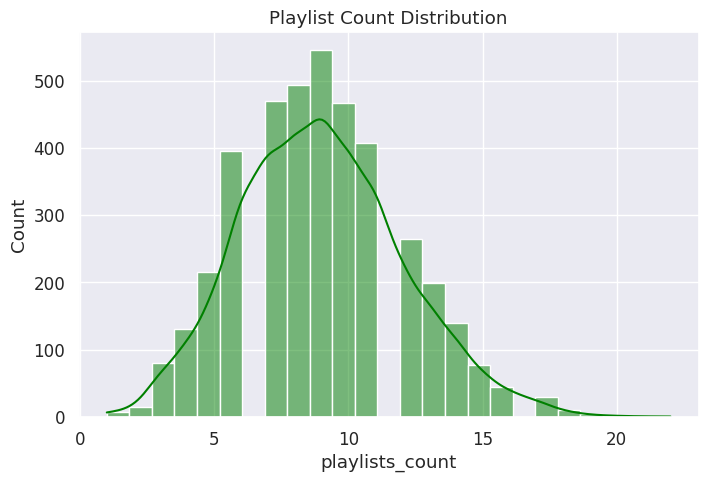

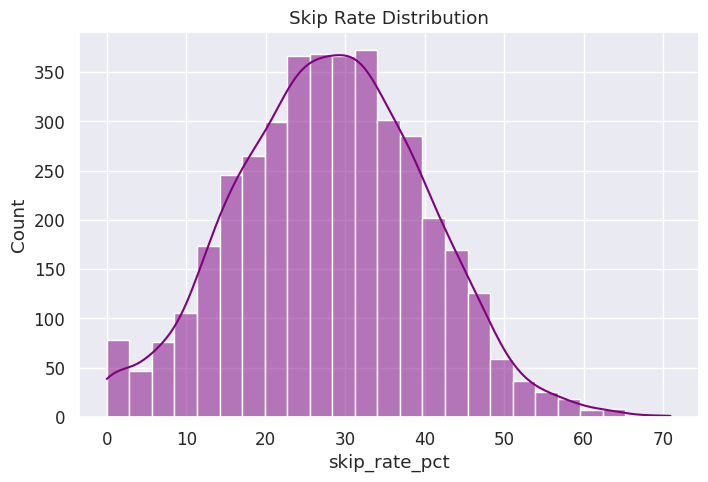

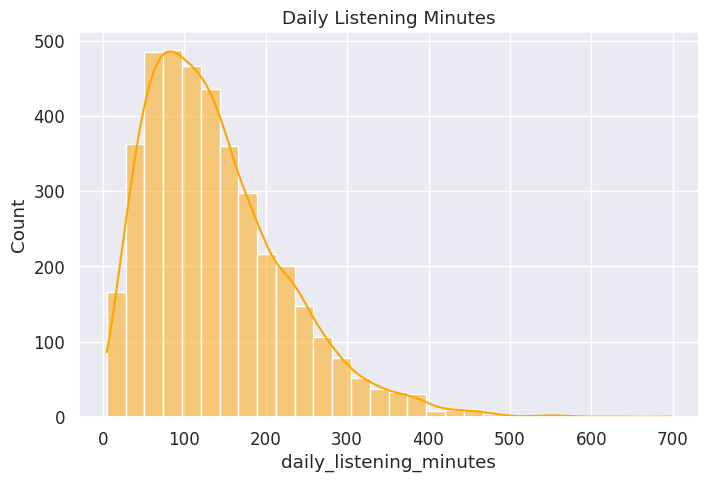

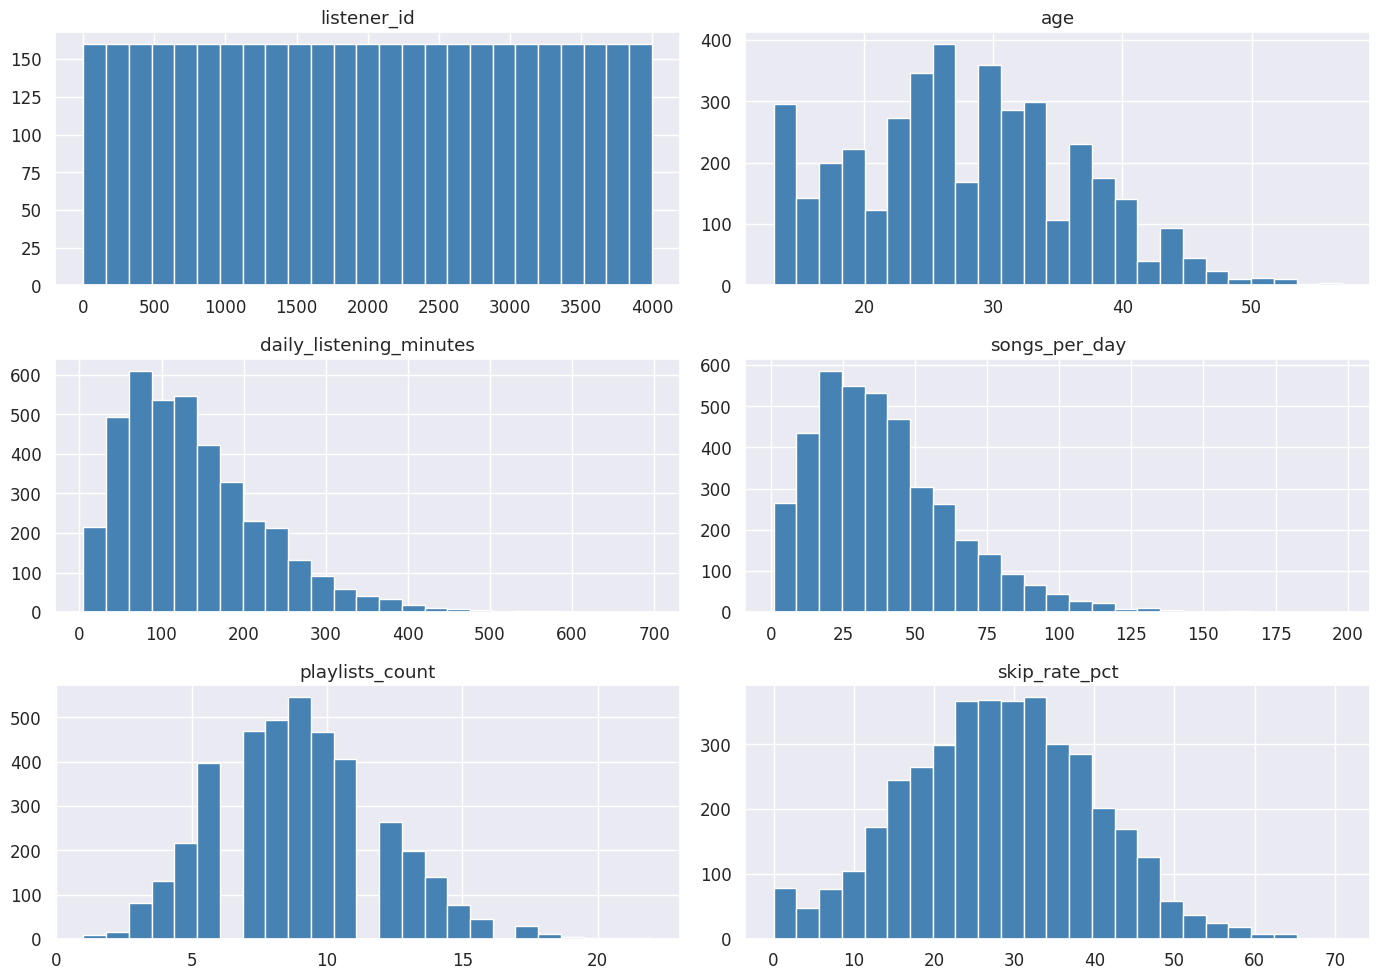

SPOTIFY DATASET EDA COMPLETED SUCCESSFULLY


In [14]:
# ==========================================================
# PART 3 : ADVANCED VISUALIZATIONS
# ==========================================================

# Scatter Plot : Age vs Daily Listening Minutes
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="age",
    y="daily_listening_minutes",
    hue="subscription",
    palette="Set2"
)

plt.title("Age vs Daily Listening Minutes")

plt.show()

# ==========================================================
# Scatter Plot : Songs Per Day vs Skip Rate
# ==========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="songs_per_day",
    y="skip_rate_pct",
    hue="platform",
    palette="tab10"
)

plt.title("Songs Per Day vs Skip Rate")

plt.show()

# ==========================================================
# Scatter Plot : Playlist Count vs Daily Listening
# ==========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="playlists_count",
    y="daily_listening_minutes",
    hue="top_mood",
    palette="Set3"
)

plt.title("Playlist Count vs Daily Listening")

plt.show()

# ==========================================================
# Violin Plot : Subscription vs Listening
# ==========================================================

plt.figure(figsize=(8,5))

sns.violinplot(
    data=data,
    x="subscription",
    y="daily_listening_minutes",
    palette="Pastel1"
)

plt.title("Subscription vs Listening Minutes")

plt.show()

# ==========================================================
# Violin Plot : Platform vs Songs
# ==========================================================

plt.figure(figsize=(10,5))

sns.violinplot(
    data=data,
    x="platform",
    y="songs_per_day",
    palette="Accent"
)

plt.xticks(rotation=45)

plt.title("Platform vs Songs Per Day")

plt.show()

# ==========================================================
# Box Plot : Genre vs Listening
# ==========================================================

plt.figure(figsize=(12,5))

sns.boxplot(
    data=data,
    x="top_genre",
    y="daily_listening_minutes",
    palette="Spectral"
)

plt.xticks(rotation=45)

plt.title("Genre vs Listening Minutes")

plt.show()

# ==========================================================
# Strip Plot
# ==========================================================

plt.figure(figsize=(10,5))

sns.stripplot(
    data=data,
    x="subscription",
    y="songs_per_day",
    hue="discover_weekly_user",
    dodge=True
)

plt.title("Songs Per Day")

plt.show()

# ==========================================================
# Swarm Plot
# ==========================================================

sample = data.sample(
    min(500,len(data)),
    random_state=42
)

plt.figure(figsize=(10,5))

sns.swarmplot(
    data=sample,
    x="uses_offline_mode",
    y="daily_listening_minutes",
    hue="subscription"
)

plt.title("Offline Mode")

plt.show()

# ==========================================================
# Correlation Heatmap
# ==========================================================

num = data.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

corr = num.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# ==========================================================
# Pair Plot
# ==========================================================

pair = [
    "age",
    "daily_listening_minutes",
    "songs_per_day",
    "playlists_count",
    "skip_rate_pct"
]

sns.pairplot(
    data[pair]
)

plt.show()

# ==========================================================
# Line Plot
# ==========================================================

age_df = data.groupby("age")["daily_listening_minutes"].mean()

plt.figure(figsize=(10,5))

plt.plot(
    age_df.index,
    age_df.values,
    marker="o",
    color="red"
)

plt.title("Average Listening Minutes by Age")

plt.xlabel("Age")

plt.ylabel("Minutes")

plt.grid(True)

plt.show()

# ==========================================================
# Platform vs Listening
# ==========================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=data,
    x="platform",
    y="daily_listening_minutes",
    palette="rocket"
)

plt.title("Average Listening Minutes by Platform")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# Subscription vs Listening
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=data,
    x="subscription",
    y="daily_listening_minutes",
    palette="viridis"
)

plt.title("Subscription vs Listening")

plt.show()

# ==========================================================
# Mood vs Listening
# ==========================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=data,
    x="top_mood",
    y="daily_listening_minutes",
    palette="magma"
)

plt.title("Mood vs Listening")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# Genre vs Songs Per Day
# ==========================================================

plt.figure(figsize=(12,5))

sns.barplot(
    data=data,
    x="top_genre",
    y="songs_per_day",
    palette="cubehelix"
)

plt.xticks(rotation=45)

plt.title("Genre vs Songs Per Day")

plt.show()

# ==========================================================
# Playlist Count Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["playlists_count"],
    bins=25,
    kde=True,
    color="green"
)

plt.title("Playlist Count Distribution")

plt.show()

# ==========================================================
# Skip Rate Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["skip_rate_pct"],
    bins=25,
    kde=True,
    color="purple"
)

plt.title("Skip Rate Distribution")

plt.show()

# ==========================================================
# Listening Minutes Distribution
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["daily_listening_minutes"],
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Daily Listening Minutes")

plt.show()

# ==========================================================
# Numerical Histogram Grid
# ==========================================================

data.select_dtypes(include=np.number).hist(
    figsize=(14,10),
    bins=25,
    color="steelblue"
)

plt.tight_layout()

plt.show()

print("="*70)
print("SPOTIFY DATASET EDA COMPLETED SUCCESSFULLY")
print("="*70)

## Features Engineering

In [15]:
# ==========================================================
# PART 1 : IMPORTS + PREPROCESSING + TRAIN TEST SPLIT
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    label_binarize
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ==========================================================
# ML ALGORITHMS
# ==========================================================

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB

# ==========================================================
# COPY DATASET
# ==========================================================

data = df.copy()

# ==========================================================
# DROP ID COLUMN
# ==========================================================

if "listener_id" in data.columns:
    data.drop(columns=["listener_id"], inplace=True)

# ==========================================================
# HANDLE MISSING VALUES
# ==========================================================

for col in data.columns:

    if data[col].dtype == "object":

        data[col].fillna(
            data[col].mode()[0],
            inplace=True
        )

    else:

        data[col].fillna(
            data[col].median(),
            inplace=True
        )

# ==========================================================
# TARGET
# ==========================================================

target = "subscription"

X = data.drop(columns=[target])

y = data[target]

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# LABEL ENCODE TARGET
# ==========================================================

target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)

y_test = target_encoder.transform(y_test)

# ==========================================================
# LABEL ENCODE FEATURES
# ==========================================================

encoders = {}

cat_cols = X_train.select_dtypes(include="object").columns

for col in cat_cols:

    encoder = LabelEncoder()

    X_train[col] = encoder.fit_transform(
        X_train[col].astype(str)
    )

    X_test[col] = X_test[col].astype(str)

    X_test[col] = X_test[col].apply(
        lambda x:
        encoder.transform([x])[0]
        if x in encoder.classes_
        else -1
    )

    encoders[col] = encoder

# ==========================================================
# IMPUTER
# ==========================================================

imputer = SimpleImputer(strategy="most_frequent")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

# ==========================================================
# FEATURE SCALING
# ==========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# ==========================================================
# MODELS
# ==========================================================

models = {

    "Logistic Regression":
    LogisticRegression(max_iter=5000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(random_state=42),

    "Extra Trees":
    ExtraTreesClassifier(
        n_estimators=200,
        random_state=42
    ),

    "AdaBoost":
    AdaBoostClassifier(random_state=42),

    "KNN":
    KNeighborsClassifier(),

    "SVM":
    SVC(
        probability=True,
        random_state=42
    ),

    "Naive Bayes":
    GaussianNB()

}

trained_models = {}

results = []

print("="*70)
print("PREPROCESSING COMPLETED SUCCESSFULLY")
print("="*70)

PREPROCESSING COMPLETED SUCCESSFULLY



Logistic Regression
Accuracy : 0.4525
Precision: 0.2064
Recall   : 0.4525
F1 Score : 0.2835

Classification Report

              precision    recall  f1-score   support

      Family       0.00      0.00      0.00       117
        Free       0.45      0.99      0.62       364
     Premium       0.00      0.00      0.00       239
     Student       0.00      0.00      0.00        80

    accuracy                           0.45       800
   macro avg       0.11      0.25      0.16       800
weighted avg       0.21      0.45      0.28       800



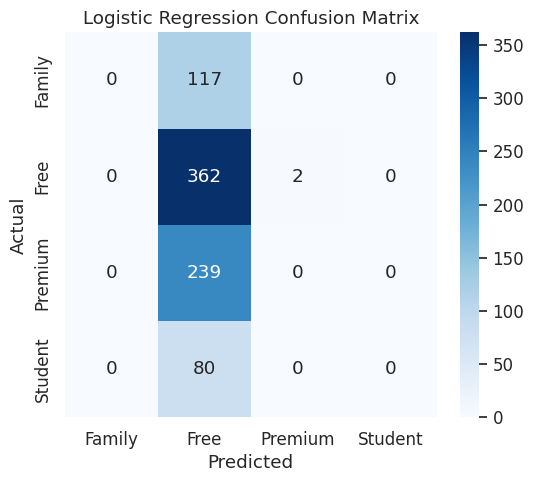

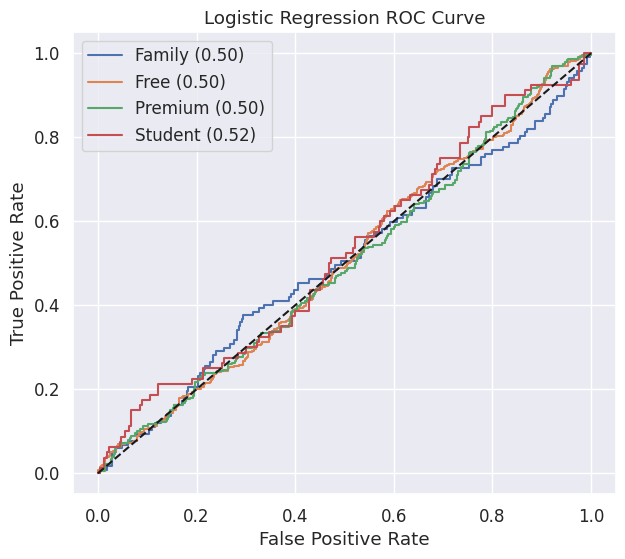


Decision Tree
Accuracy : 0.3375
Precision: 0.3380
Recall   : 0.3375
F1 Score : 0.3372

Classification Report

              precision    recall  f1-score   support

      Family       0.14      0.16      0.15       117
        Free       0.46      0.47      0.46       364
     Premium       0.33      0.29      0.31       239
     Student       0.12      0.11      0.12        80

    accuracy                           0.34       800
   macro avg       0.26      0.26      0.26       800
weighted avg       0.34      0.34      0.34       800



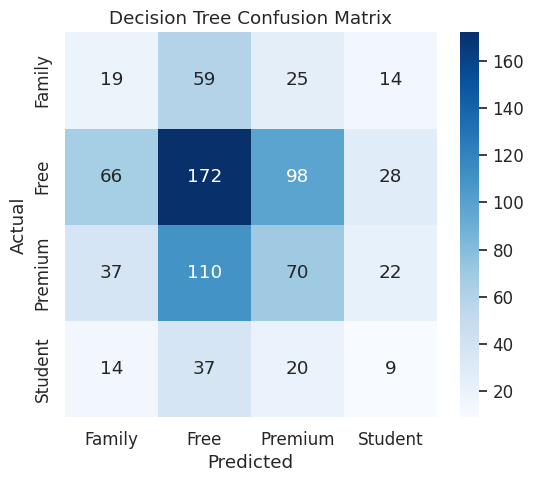

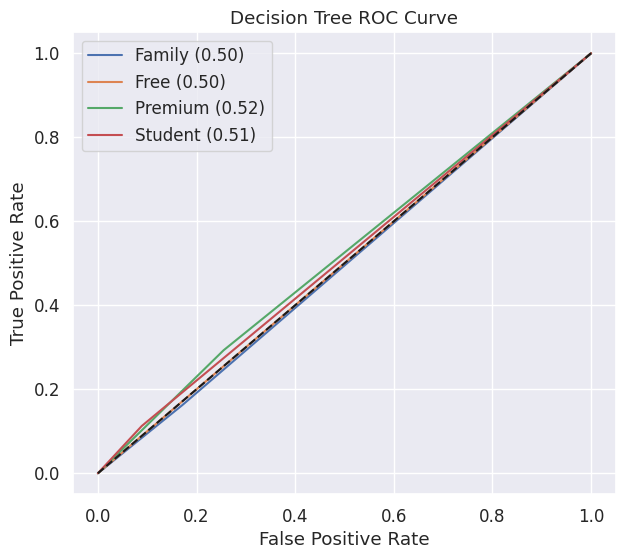


Random Forest
Accuracy : 0.4412
Precision: 0.3152
Recall   : 0.4412
F1 Score : 0.3401

Classification Report

              precision    recall  f1-score   support

      Family       0.00      0.00      0.00       117
        Free       0.46      0.86      0.60       364
     Premium       0.36      0.17      0.23       239
     Student       0.00      0.00      0.00        80

    accuracy                           0.44       800
   macro avg       0.20      0.26      0.21       800
weighted avg       0.32      0.44      0.34       800



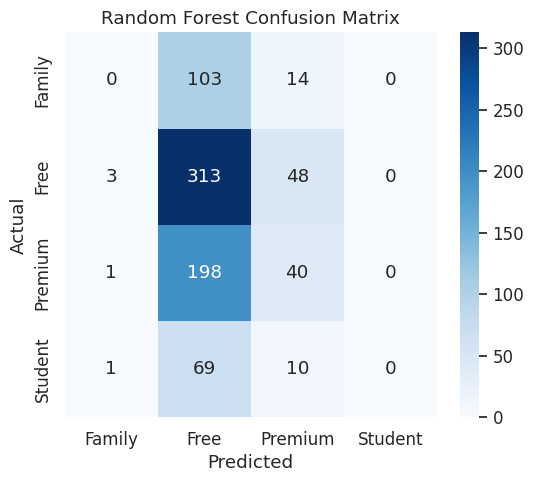

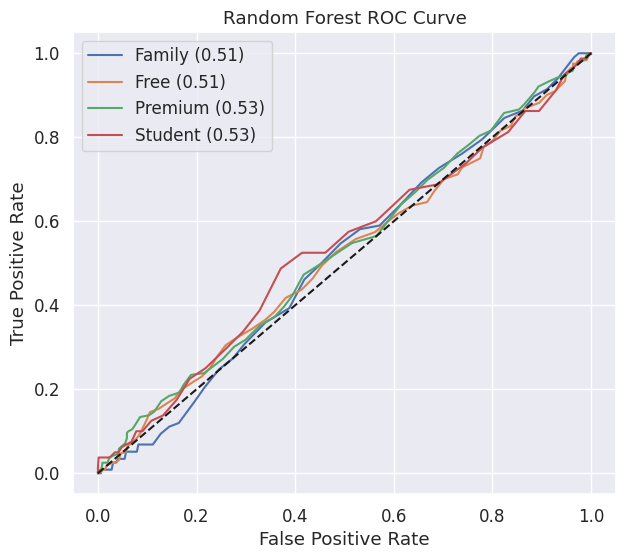


Gradient Boosting
Accuracy : 0.4288
Precision: 0.3163
Recall   : 0.4288
F1 Score : 0.3172

Classification Report

              precision    recall  f1-score   support

      Family       0.20      0.02      0.03       117
        Free       0.45      0.88      0.60       364
     Premium       0.27      0.09      0.14       239
     Student       0.00      0.00      0.00        80

    accuracy                           0.43       800
   macro avg       0.23      0.25      0.19       800
weighted avg       0.32      0.43      0.32       800



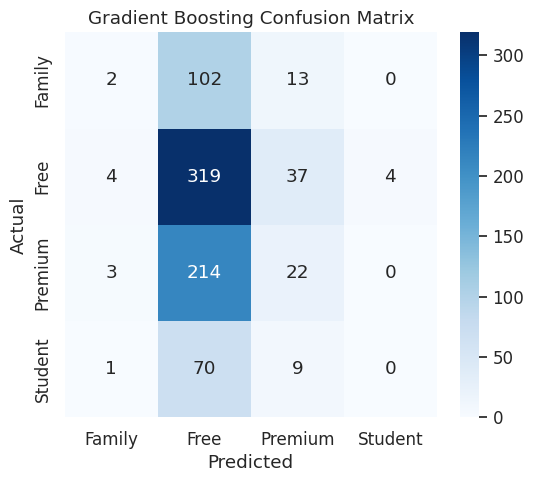

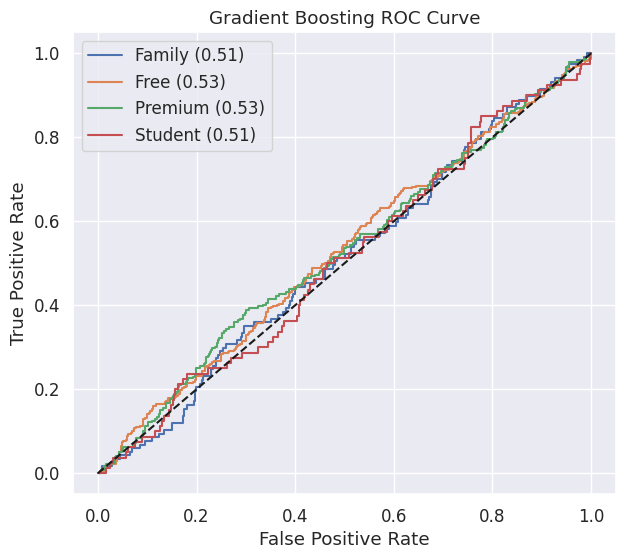


Extra Trees
Accuracy : 0.4250
Precision: 0.3293
Recall   : 0.4250
F1 Score : 0.3310

Classification Report

              precision    recall  f1-score   support

      Family       0.20      0.01      0.02       117
        Free       0.44      0.82      0.58       364
     Premium       0.33      0.17      0.22       239
     Student       0.00      0.00      0.00        80

    accuracy                           0.42       800
   macro avg       0.24      0.25      0.20       800
weighted avg       0.33      0.42      0.33       800



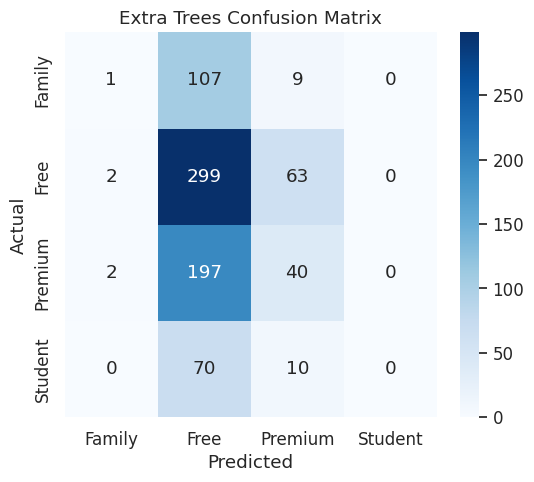

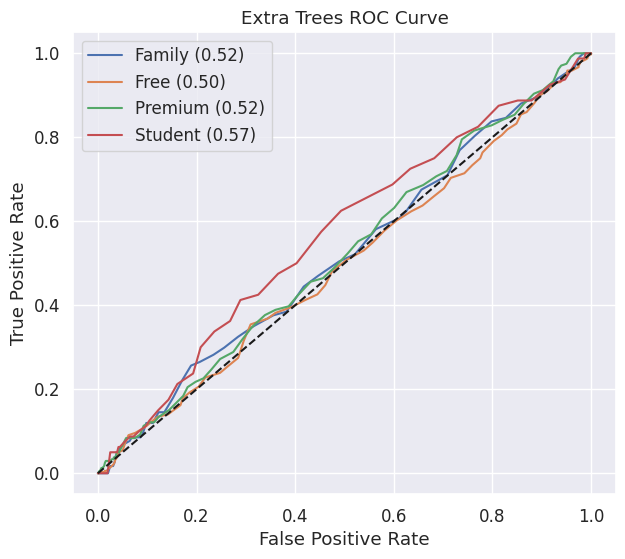


AdaBoost
Accuracy : 0.4550
Precision: 0.2070
Recall   : 0.4550
F1 Score : 0.2846

Classification Report

              precision    recall  f1-score   support

      Family       0.00      0.00      0.00       117
        Free       0.46      1.00      0.63       364
     Premium       0.00      0.00      0.00       239
     Student       0.00      0.00      0.00        80

    accuracy                           0.46       800
   macro avg       0.11      0.25      0.16       800
weighted avg       0.21      0.46      0.28       800



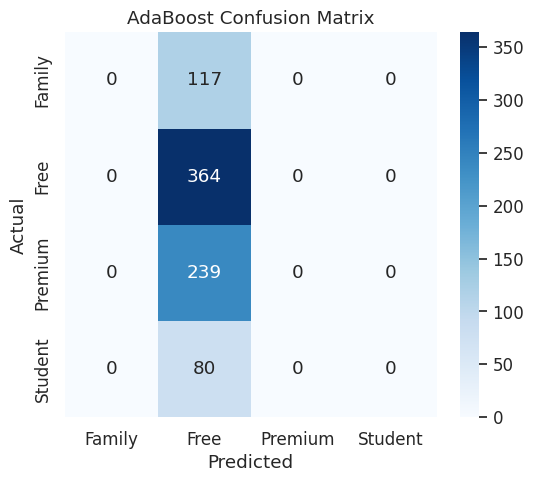

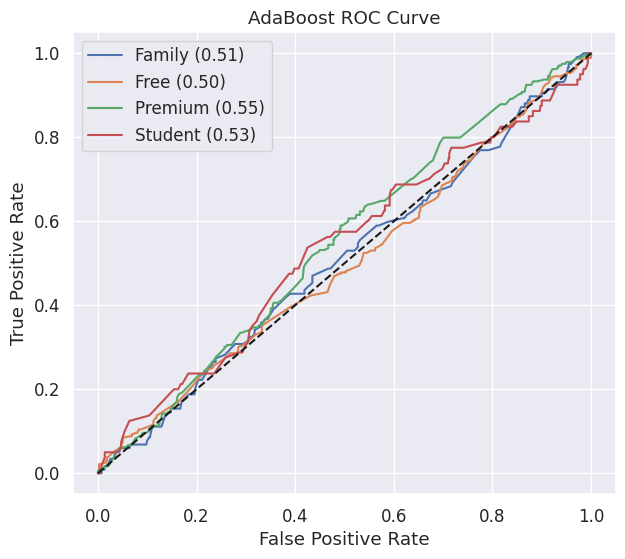


KNN
Accuracy : 0.3713
Precision: 0.3254
Recall   : 0.3713
F1 Score : 0.3391

Classification Report

              precision    recall  f1-score   support

      Family       0.13      0.12      0.13       117
        Free       0.45      0.62      0.52       364
     Premium       0.31      0.24      0.27       239
     Student       0.06      0.01      0.02        80

    accuracy                           0.37       800
   macro avg       0.24      0.25      0.24       800
weighted avg       0.33      0.37      0.34       800



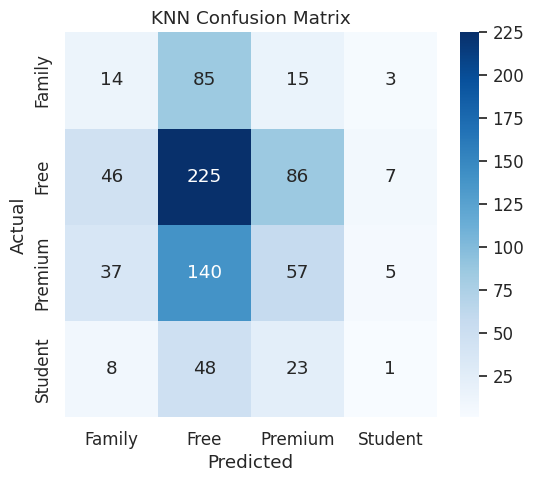

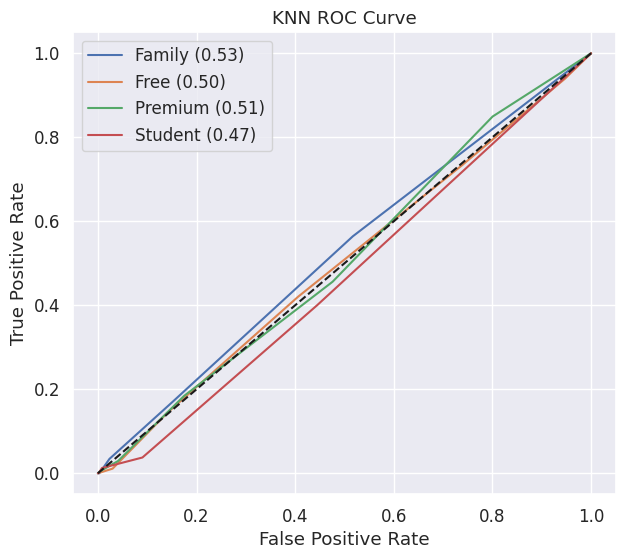


SVM
Accuracy : 0.4512
Precision: 0.3145
Recall   : 0.4512
F1 Score : 0.2913

Classification Report

              precision    recall  f1-score   support

      Family       0.00      0.00      0.00       117
        Free       0.45      0.98      0.62       364
     Premium       0.36      0.02      0.03       239
     Student       0.00      0.00      0.00        80

    accuracy                           0.45       800
   macro avg       0.20      0.25      0.16       800
weighted avg       0.31      0.45      0.29       800



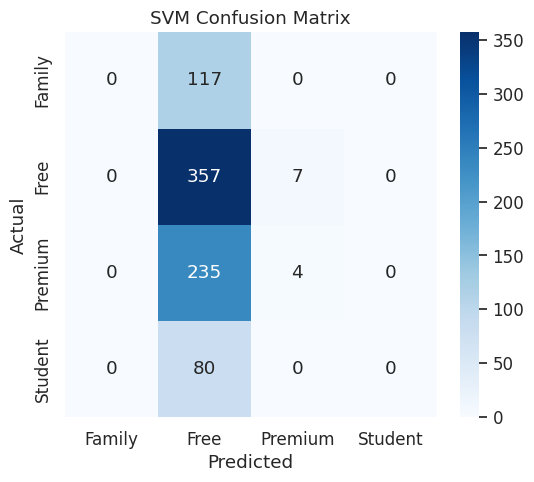

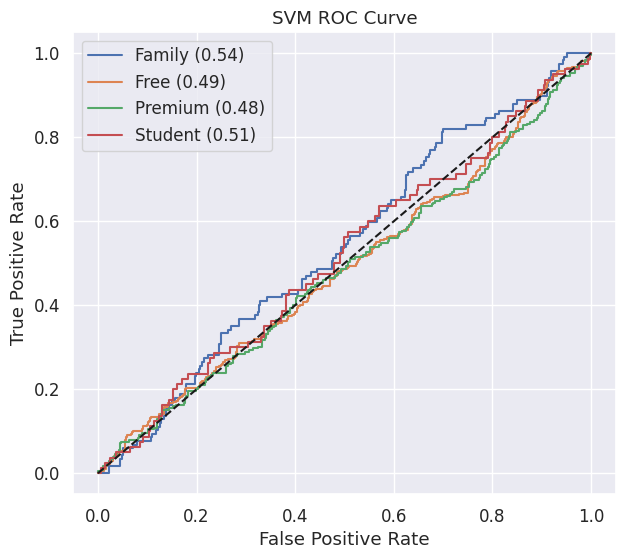


Naive Bayes
Accuracy : 0.4562
Precision: 0.5060
Recall   : 0.4562
F1 Score : 0.2873

Classification Report

              precision    recall  f1-score   support

      Family       0.00      0.00      0.00       117
        Free       0.46      1.00      0.63       364
     Premium       1.00      0.00      0.01       239
     Student       0.00      0.00      0.00        80

    accuracy                           0.46       800
   macro avg       0.36      0.25      0.16       800
weighted avg       0.51      0.46      0.29       800



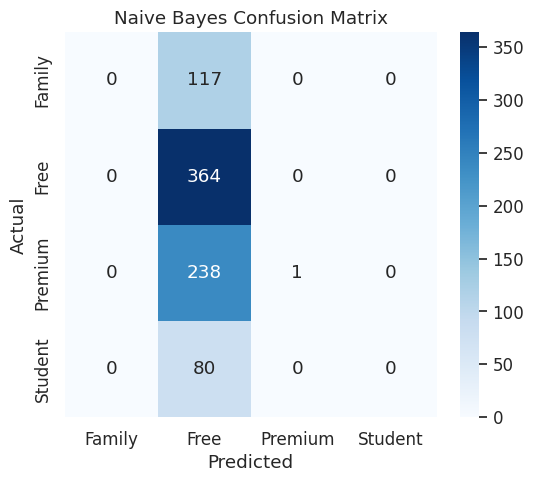

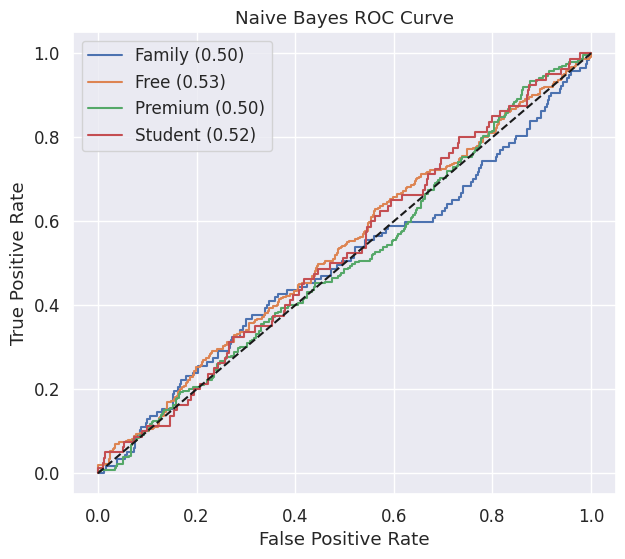



MODEL COMPARISON
                 Model  Accuracy  Precision   Recall  F1 Score
8          Naive Bayes   0.45625   0.506034  0.45625  0.287305
5             AdaBoost   0.45500   0.207025  0.45500  0.284570
0  Logistic Regression   0.45250   0.206404  0.45250  0.283494
7                  SVM   0.45125   0.314511  0.45125  0.291321
2        Random Forest   0.44125   0.315210  0.44125  0.340135
3    Gradient Boosting   0.42875   0.316271  0.42875  0.317237
4          Extra Trees   0.42500   0.329348  0.42500  0.330984
6                  KNN   0.37125   0.325404  0.37125  0.339148
1        Decision Tree   0.33750   0.337979  0.33750  0.337208


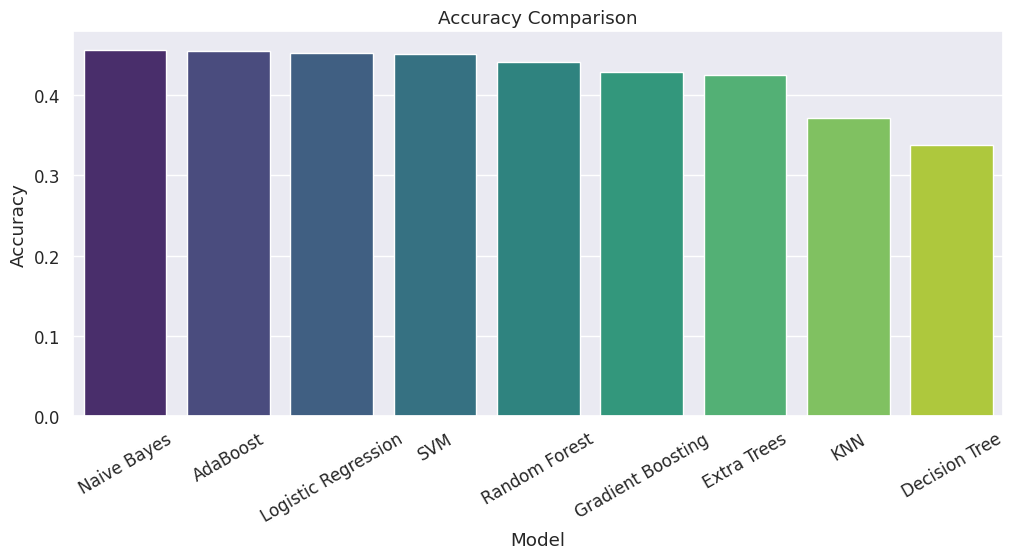

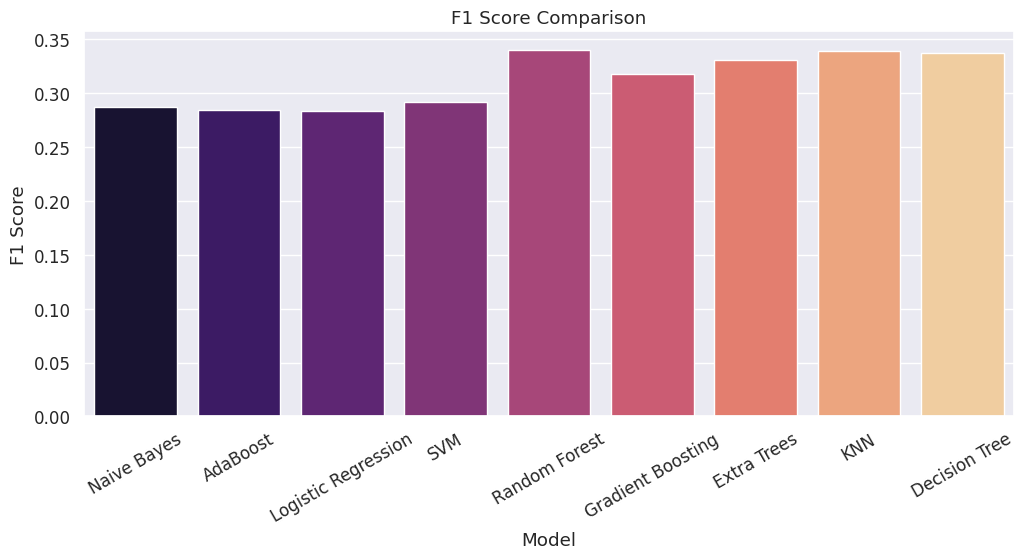

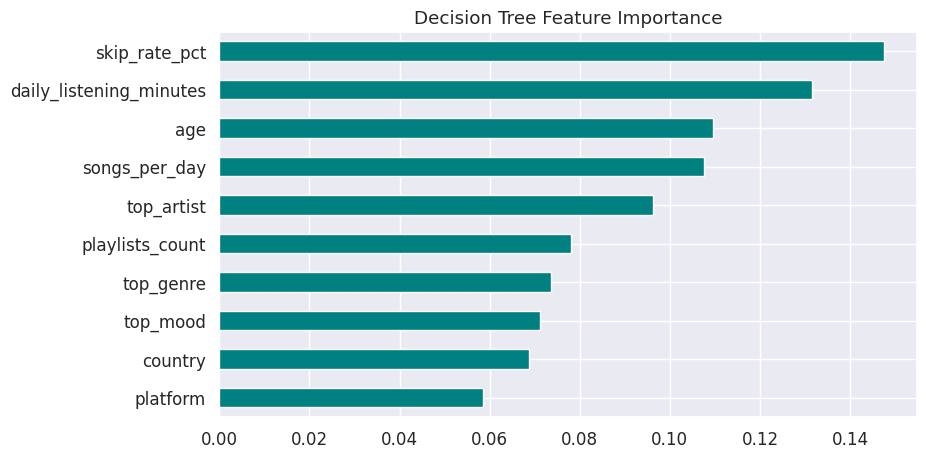

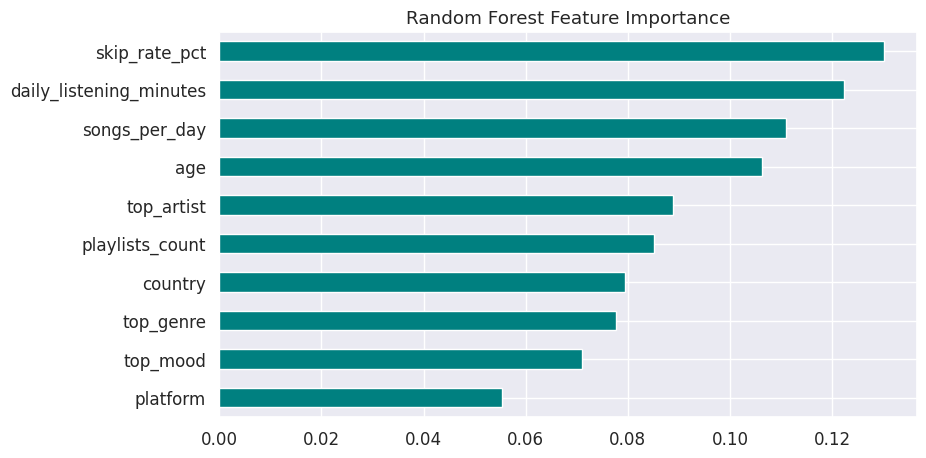

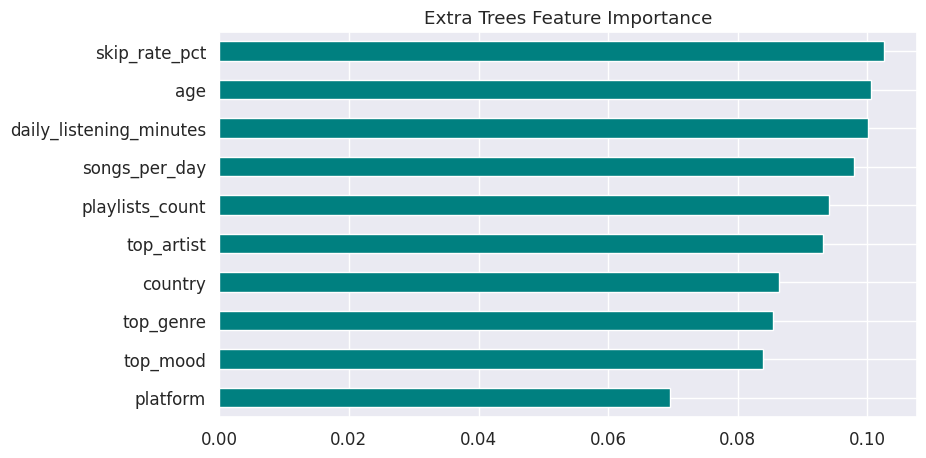



BEST MODEL
Model        Naive Bayes
Accuracy         0.45625
Precision       0.506034
Recall           0.45625
F1 Score        0.287305
Name: 8, dtype: object

Best Model : Naive Bayes
Accuracy   : 0.4562
Precision  : 0.506
Recall     : 0.4562
F1 Score   : 0.2873

Results saved as Spotify_Model_Comparison.csv


PIPELINE COMPLETED SUCCESSFULLY


In [16]:
# ==========================================================
# PART 2 : TRAINING + EVALUATION + ROC + MODEL COMPARISON
# ==========================================================

from sklearn.preprocessing import label_binarize

n_classes = len(target_encoder.classes_)

# ==========================================================
# TRAIN ALL MODELS
# ==========================================================

for name, model in models.items():

    print("\n" + "="*80)
    print(name)
    print("="*80)

    # -------------------------
    # Train
    # -------------------------

    model.fit(X_train, y_train)

    trained_models[name] = model

    # -------------------------
    # Prediction
    # -------------------------

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    pre = precision_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )

    rec = recall_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

    results.append([
        name,
        acc,
        pre,
        rec,
        f1
    ])

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    print("\nClassification Report\n")

    print(
        classification_report(
            y_test,
            pred,
            target_names=target_encoder.classes_,
            zero_division=0
        )
    )

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_encoder.classes_,
        yticklabels=target_encoder.classes_
    )

    plt.title(name + " Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # =====================================================
    # ROC CURVE
    # =====================================================

    if hasattr(model, "predict_proba"):

        probs = model.predict_proba(X_test)

        y_bin = label_binarize(
            y_test,
            classes=np.arange(n_classes)
        )

        plt.figure(figsize=(7,6))

        # Binary Classification
        if n_classes == 2:

            fpr, tpr, _ = roc_curve(
                y_bin[:,1],
                probs[:,1]
            )

            roc_auc = auc(fpr,tpr)

            plt.plot(
                fpr,
                tpr,
                label=f"AUC = {roc_auc:.3f}"
            )

        else:

            # Multi-Class
            for i in range(n_classes):

                fpr,tpr,_ = roc_curve(
                    y_bin[:,i],
                    probs[:,i]
                )

                roc_auc = auc(fpr,tpr)

                plt.plot(
                    fpr,
                    tpr,
                    label=f"{target_encoder.classes_[i]} ({roc_auc:.2f})"
                )

        plt.plot([0,1],[0,1],"k--")

        plt.xlabel("False Positive Rate")

        plt.ylabel("True Positive Rate")

        plt.title(name + " ROC Curve")

        plt.legend()

        plt.grid(True)

        plt.show()

# ==========================================================
# MODEL COMPARISON
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*80)
print("MODEL COMPARISON")
print("="*80)

print(results_df)

# ==========================================================
# ACCURACY GRAPH
# ==========================================================

plt.figure(figsize=(12,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.xticks(rotation=30)

plt.title("Accuracy Comparison")

plt.show()

# ==========================================================
# F1 SCORE GRAPH
# ==========================================================

plt.figure(figsize=(12,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score",
    palette="magma"
)

plt.xticks(rotation=30)

plt.title("F1 Score Comparison")

plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

feature_names = X.columns

for model_name in [
    "Decision Tree",
    "Random Forest",
    "Extra Trees"
]:

    model = trained_models[model_name]

    importance = pd.Series(
        model.feature_importances_,
        index=feature_names
    )

    importance = importance.sort_values(
        ascending=False
    )

    plt.figure(figsize=(9,5))

    importance.head(10).plot(
        kind="barh",
        color="teal"
    )

    plt.title(model_name + " Feature Importance")

    plt.gca().invert_yaxis()

    plt.show()

# ==========================================================
# BEST MODEL
# ==========================================================

best = results_df.iloc[0]

print("\n")
print("="*80)
print("BEST MODEL")
print("="*80)

print(best)

print("\nBest Model :", best["Model"])
print("Accuracy   :", round(best["Accuracy"],4))
print("Precision  :", round(best["Precision"],4))
print("Recall     :", round(best["Recall"],4))
print("F1 Score   :", round(best["F1 Score"],4))

# ==========================================================
# SAVE RESULTS
# ==========================================================

results_df.to_csv(
    "Spotify_Model_Comparison.csv",
    index=False
)

print("\nResults saved as Spotify_Model_Comparison.csv")

print("\n")
print("="*80)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("="*80)

## Thanks..................Please Upvote